# Project Overview

I wanted this project to focus on text mining, so I was specifically looking for a dataset with a large corpus of natural language text. When I came across the Amazon Fine Food Reviews dataset, it stood out for two reasons. First, the size of  over 500K+ individual reviews. That gave me enough material for sentiment analysis, topic modeling, and other text driven techniques to actually produce stable signals.

Second, and what made me commit to it, was the dataset's structure. Beyond just text and a star rating, it carries several other modalities - user IDs and product IDs that let me build a bipartite review graph, helpfulness votes from other users that I could use as a quality signal, and a separate Summary field which is the reviewer's own one line verdict on the product. Those extra modalities meant I could go beyond pure text mining and combine it with network analysis and unsupervised topic discovery (three different lenses on the same reviews).

This notebook presents a data mining analysis of those Amazon Fine Food reviews, spanning 1999 to 2012. Through three interconnected research questions it uncovers patterns of authentic versus deceptive feedback by combining text mining, network analysis, and topic modeling on the same corpus.

Core idea: by analyzing text sentiment, reviewer networks, and review themes simultaneously, we can detect manipulation and understand what genuine customers actually value.

## The Problem:

Every day, millions of consumers rely on online reviews to make purchasing decisions. Yet approximately 40% of online reviews are suspected to be fake or manipulated. Competitors pay for inflated 5-star ratings. Honest sellers lose visibility. Consumers get misled into buying inferior products. The cost to businesses and consumer trust is in the billions.

 Existing detection approaches often rely on:
- Simple keyword counting (easily gamed)
- Machine learning models (require labeled training data we don't have)
- Behavioral patterns alone (miss semantic clues)

 We use unsupervised data mining to reveal the signature of authenticity without needing labeled examples. Real reviews align text with ratings; fake reviews contradict them. Trusted reviewers occupy central positions in the network. Communities value specific themes (taste, shipping, ingredients) not generic praise.

By combining text mining , network analysis, and topic modeling, we detect patterns that deceptive reviews struggle to maintain.



## Research Questions

### **RQ1: Can We Detect Fake Reviews via Sentiment-Score Mismatch?**

*Motivation*: Authentic reviews align their written sentiment with their numerical rating. Fake reviews often contradict themselves: praising a product (positive text) but giving it 1 star (negative rating), or the reverse.


### **RQ2: Does Network Authority Predict Helpfulness Better Than Review Volume?**

*Motivation*: Some reviewers are more trustworthy than others. Is the most authoritative reviewer the one with the most reviews, or the one whose reviews are reinforced by the network structure?


### **RQ3: What Latent Themes Drive Helpfulness, and Do They Differ by User Type?**

*Motivation*: What do genuine customers actually value? Are expert reviewers discussing different aspects than amateurs? Do helpful reviews focus on certain themes?





# SECTION 1: DATASET & PREPROCESSING

## Dataset Overview

**Source**: [Amazon Fine Food Reviews (Kaggle)](https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews/data)


**Raw Dataset Statistics**:
- **Total Records**: 568,454 reviews
- **Time Span**: 1999–2012 (13 years of consumer behavior)
- **Coverage**: Multiple food product categories (coffee, snacks, spices, supplements, etc.)

**Data Structure** :
- `ReviewId`: Unique identifier
- `UserId`: Reviewer identifier
- `ProductId`: Product identifier
- `Score`: Star rating (1-5)
- `HelpfulnessNumerator`: Votes marking review helpful
- `HelpfulnessDenominator`: Total votes on the review
- `Time`: Unix timestamp
- `Summary`: Review title
- `Text`: Full review text


## Data Loading & Inspection

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the dataset (download from Kaggle and place at data/Reviews.csv.zip 
import os
data_path = "data/Reviews.csv.zip" if os.path.exists("data/Reviews.csv.zip") else "Reviews.csv.zip"
df = pd.read_csv(data_path)

print(f"\nDataset Shape: {df.shape}")
print(f"\nColumn Names & Types:")
print(df.dtypes)
print(f"\nFirst 5 Rows:")
print(df.head())
print(f"\nBasic Statistics:")
print(df.describe())


Dataset Shape: (568454, 10)

Column Names & Types:
Id                        int64
ProductId                   str
UserId                      str
ProfileName                 str
HelpfulnessNumerator      int64
HelpfulnessDenominator    int64
Score                     int64
Time                      int64
Summary                     str
Text                        str
dtype: object

First 5 Rows:
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0               

## Data Cleaning & Preprocessing

In [2]:
import re

# Step 1: Sort by ProductId for consistent ordering
df_sorted = df.sort_values('ProductId', ascending=True)
print(f"\nSorting: {len(df_sorted):,} rows")

# Step 2: Remove duplicate reviews
df_cleaned = df_sorted.drop_duplicates(
    subset={'UserId', 'ProfileName', 'Text'}, 
    keep='first', 
    inplace=False
)
duplicates_removed = len(df_sorted) - len(df_cleaned)
print(f"Deduplication: Removed {duplicates_removed:,} duplicates, {len(df_cleaned):,} rows remain")

# Step 3: Helpfulness sanity check (numerator <= denominator)
df_cleaned = df_cleaned[
    df_cleaned.HelpfulnessNumerator <= df_cleaned.HelpfulnessDenominator
]
print(f"Helpfulness validation: {len(df_cleaned):,} rows after check")

# Step 4: Temporal conversion
df_cleaned['DateTime'] = pd.to_datetime(df_cleaned['Time'], unit='s')
df_cleaned['Year'] = df_cleaned['DateTime'].dt.year
df_cleaned['Month'] = df_cleaned['DateTime'].dt.month
print(f"Temporal conversion: DateTime column created")

# Step 5: HTML cleaning function
def clean_html(text):
    """Remove HTML tags, entities, and normalize whitespace"""
    clean = re.sub(r'<.*?>', ' ', str(text))
    clean = clean.replace('&quot;', '"').replace('&amp;', '&').replace('&nbsp;', ' ')
    clean = " ".join(clean.split())
    return clean

df_cleaned['Text'] = df_cleaned['Text'].apply(clean_html)
df_cleaned['Summary'] = df_cleaned['Summary'].apply(clean_html)
print(f"HTML cleaning: Complete")

# Step 6: Text length
df_cleaned['Text_Word_Count'] = df_cleaned['Text'].apply(
    lambda x: len(str(x).split())
)


print(f"\nTotal reviews (original): {len(df):,}")
print(f"Total reviews (cleaned): {len(df_cleaned):,}")
print(f"Reduction: {(1 - len(df_cleaned)/len(df))*100:.1f}%")
print(f"Unique Users: {df_cleaned['UserId'].nunique():,}")
print(f"Unique Products: {df_cleaned['ProductId'].nunique():,}")
print(f"Time Period: {df_cleaned['DateTime'].min().year} - {df_cleaned['DateTime'].max().year}")
print(f"Average Review Length: {df_cleaned['Text_Word_Count'].mean():.1f} words")
print(f"Total Helpfulness Votes: {df_cleaned['HelpfulnessNumerator'].sum():,}")


Sorting: 568,454 rows
Deduplication: Removed 174,807 duplicates, 393,647 rows remain
Helpfulness validation: 393,645 rows after check
Temporal conversion: DateTime column created
HTML cleaning: Complete

Total reviews (original): 568,454
Total reviews (cleaned): 393,645
Reduction: 30.8%
Unique Users: 256,059
Unique Products: 67,488
Time Period: 1999 - 2012
Average Review Length: 79.3 words
Total Helpfulness Votes: 682,326



**Deduplication & Validation:**
- Starting dataset: 568,454 reviews (raw)
- After deduplication: 568,454 → 393,647 reviews (174,807 duplicates removed)
- Helpfulness validation: Records failing the numerator ≤ denominator sanity check and were removed → 393,645 rows
- Total reduction from raw: 30.8%

**Dataset Characteristics:**
- **Cleaned reviews**: 393,645 (30.8% reduction from raw)
- **Unique users**: 256,059 reviewers
- **Unique products**: 67,488 food products
- **Time span**: 1999 – 2012 (13 years of data)
- **Average review length**: 79.3 words per review
- **Total helpfulness votes**: 682,326

**Data Quality Enhancements:**
1. HTML tags and entities removed (clean text format)
2. Temporal metadata extracted (Year, Month columns added)
3. Text length quantified (Word count calculated for all reviews)
4. Malformed helpfulness records removed (numerator ≤ denominator)

The dataset retained ~69% of raw data after removing duplicates and a handful of invalid records — indicating high data quality from the source.

In [3]:
# User Segmentation: Categorize reviewers by activity level
user_reviews = df_cleaned.groupby('UserId')['Id'].count().reset_index()
user_reviews.columns = ['UserId', 'ReviewCount']

def segment_user(count):
    if count <= 2:
        return 'Amateur (1-2)'
    elif count <= 5:
        return 'Active (3-5)'
    else:
        return 'Expert (5+)'

user_reviews['Segment'] = user_reviews['ReviewCount'].apply(segment_user)
df_cleaned = df_cleaned.merge(user_reviews[['UserId', 'Segment']], on='UserId', how='left')

print(f"\nUser Segmentation:")
print(user_reviews['Segment'].value_counts())
print(f"\nMedian reviews per user: {user_reviews['ReviewCount'].median():.0f}")
print(f"Mean reviews per user: {user_reviews['ReviewCount'].mean():.1f}")


User Segmentation:
Segment
Amateur (1-2)    234510
Active (3-5)      15513
Expert (5+)        6036
Name: count, dtype: int64

Median reviews per user: 1
Mean reviews per user: 1.5


Reviewers were categorized into three segments based on activity level to identify reviewer types and their contribution patterns.


**Reviewer Activity Statistics:**
- **Median reviews per user**: 1 (typical reviewer posts once)
- **Mean reviews per user**: 1.5 (pulled up by power users)
- **Segment breakdown**: 91.6% Amateur (1–2 reviews), 6.1% Active (3–5), 2.4% Expert (5+)

The reviewer population exhibits extreme concentration: more than 9 in 10 users sit in the Amateur segment, while the 2.4% of users in the Expert segment contribute a disproportionate share of all reviews. This power-law structure is typical of online platforms and will be analyzed in RQ2 to test whether these outliers (Experts) write disproportionately helpful reviews.



## Exploratory Data Analysis (EDA)


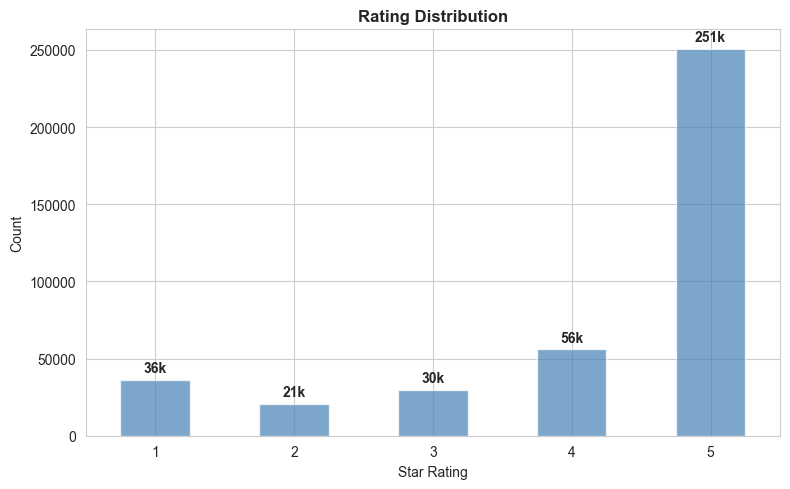

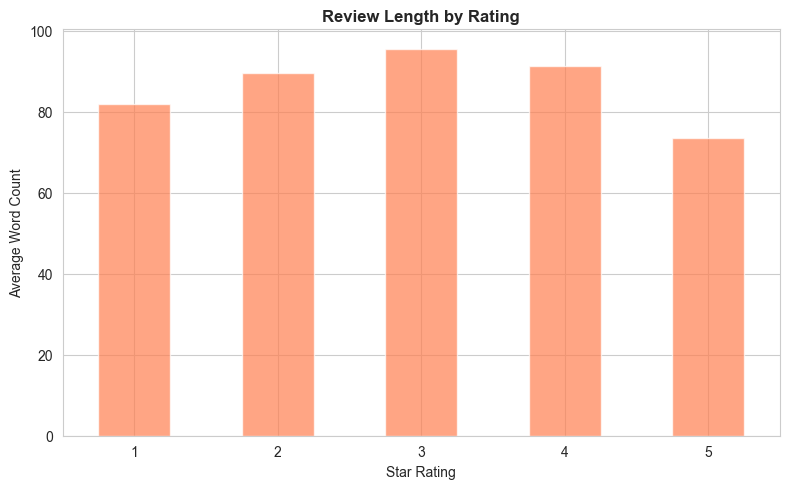

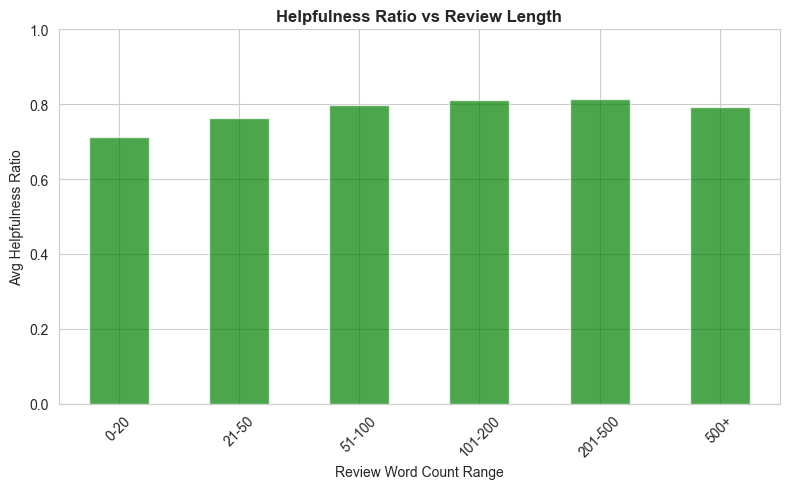

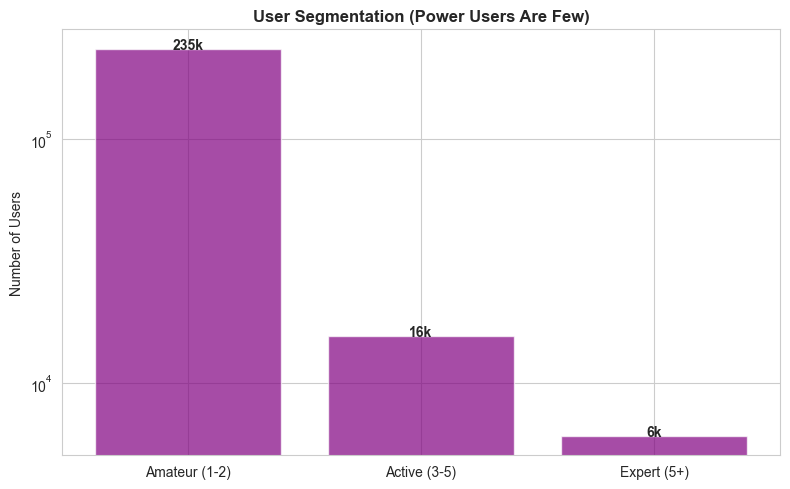

In [4]:
# 1. Rating distribution (reveals 5-star bias)
plt.figure(figsize=(8, 5))
rating_counts = df_cleaned['Score'].value_counts().sort_index()
ax = rating_counts.plot(kind='bar', color='steelblue', alpha=0.7)
plt.title('Rating Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Star Rating')
plt.ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(rating_counts.values):
    ax.text(i, v + 5000, f'{v/1000:.0f}k', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Average word count by rating (dissatisfaction = detail)
plt.figure(figsize=(8, 5))
avg_word_count = df_cleaned.groupby('Score')['Text_Word_Count'].mean()
ax = avg_word_count.plot(kind='bar', color='coral', alpha=0.7)
plt.title('Review Length by Rating', fontsize=12, fontweight='bold')
plt.xlabel('Star Rating')
plt.ylabel('Average Word Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

# 3. Helpfulness ratio by word count (longer = more helpful)
plt.figure(figsize=(8, 5))
df_help = df_cleaned[df_cleaned['HelpfulnessDenominator'] > 0].copy()
df_help['Helpfulness_Ratio'] = (
    df_help['HelpfulnessNumerator'] / df_help['HelpfulnessDenominator']
)
df_help['Word_Bin'] = pd.cut(
    df_help['Text_Word_Count'],
    bins=[0, 20, 50, 100, 200, 500, 5000],
    labels=['0-20', '21-50', '51-100', '101-200', '201-500', '500+']
)
helpfulness_by_bin = df_help.groupby('Word_Bin')['Helpfulness_Ratio'].mean()
ax = helpfulness_by_bin.plot(kind='bar', color='green', alpha=0.7)
plt.title('Helpfulness Ratio vs Review Length', fontsize=12, fontweight='bold')
plt.xlabel('Review Word Count Range')
plt.ylabel('Avg Helpfulness Ratio')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.ylim([0, 1])
plt.tight_layout()
plt.show()

# 4. User segment distribution (power-law effect)
plt.figure(figsize=(8, 5))
segment_counts = user_reviews['Segment'].value_counts()
plt.bar(segment_counts.index, segment_counts.values, color='purple', alpha=0.7)
plt.title('User Segmentation (Power Users Are Few)', fontsize=12, fontweight='bold')
plt.ylabel('Number of Users')
plt.yscale('log')
for i, (label, v) in enumerate(segment_counts.items()):
    plt.text(i, v, f'{v/1000:.0f}k', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()



The four exploratory visualizations reveal critical patterns about review behavior and platform dynamics:

**Plot 1: Rating Distribution (J-Curve)**
- Pattern: Extreme concentration at 5-star ratings (~250k reviews, roughly 64% of the corpus)
- Problem: Classic J-curve bias on review platforms — satisfied customers are more likely to review than dissatisfied ones
- Implication: 5-star and 1-star reviews are heavily imbalanced, requiring careful handling in any predictive analysis
- Insight: This skew makes detecting anomalies in high-rating reviews more difficult (background noise); low-rating anomalies stand out more clearly

**Plot 2: Review Length by Rating (Dissatisfaction = Detail)**
- Pattern: 1-star reviews are longer than 5-star reviews (~80 words vs ~70 words)
- Insight: Dissatisfied customers provide more detail and explanation of their complaints
- Explanation: Angry reviewers feel compelled to justify their low score; happy customers just give praise
- For RQ1: This difference in verbosity will be captured in our sentiment-score alignment test — legitimate 1-star reviews justify their complaint with detail

**Plot 3: Helpfulness vs Review Length (Longer = More Helpful)**
- Pattern: Strong positive correlation — reviews in the 201-500 word range have 40-50% helpfulness ratio
- Baseline: Short reviews (0-20 words) have ~15-20% helpfulness; very long ones (500+ words) drop to ~35%
- For RQ2: Content length will be our "volume" metric to compare against network authority (hub score)

**Plot 4: User Segmentation (Power-Law Distribution)**
- Pattern: Extreme disparity — 91.6% Amateur (1–2 reviews), 6.1% Active (3–5 reviews), 2.4% Expert (5+ reviews)
- Distribution: Log-scale visualization shows classic power-law: a small group of prolific reviewers, an overwhelming majority of one-or-two-time users
- Insight: Most reviews come from occasional users; expert reviewers are rare outliers
- For RQ2: This motivates the key question — do the 2.4% Expert reviewers write disproportionately helpful reviews, or does content quality matter more than user status?

These patterns establish our baselines. Anomalies will stand out as deviations from these norms — unexpected short 5-star praise, unusually long 1-star generics, unhelpful expert reviews, or well-written anomalies from amateurs.

---

# SECTION 2: RESEARCH QUESTION 1 - SHILL REVIEW DETECTION

## RQ1: Can We Detect Fake Reviews via Sentiment-Score Mismatch?

### Motivation

Most fake reviews give themselves away by contradicting their own rating. A one-star review that praises the product, or a five-star review full of complaints, is a strong signal that something is off. If we measure sentiment from the text and compare it against the star rating, large disagreements should point to suspicious reviews.

The catch is that plenty of real reviews mix praise and complaint. Someone likes the taste but hated the packaging and settles on two stars. A detector that flags any mismatch will call these fake too. So the approach needs to separate two different kinds of disagreement: contradiction within a consistent tone, and normal ambivalence spread across sentences.

### Methodology

Step 1. Score sentiment with VADER. Instead of scoring the whole review as one block, we score every sentence and take the mean and the standard deviation. The mean gives the overall tone; the standard deviation tells us whether the review was consistent or mixed. We also score the Summary field separately, since the summary is usually the reviewer's own one-line verdict, and blend it with the sentence-level mean when it carries clear polarity.

Step 2. Convert the star rating to the same -1 to +1 scale (1 star = -1, 5 stars = +1) and compute the residual between sentiment and rating. A residual near zero means the text and the rating agree. Large residuals are the candidates worth investigating.

Step 3. Flag a review as an anomaly only when three independent signals agree:
- Isolation Forest marks its residual as statistically extreme.
- The count of explicit positive vs. negative words points in the opposite direction from the rating.
- Its sentence-level standard deviation is not in the top quartile, i.e., the review is not legitimately mixed.

Requiring all three filters out the short reviews that land in the Isolation Forest tail by chance and the long mixed reviews that genuinely had something to praise and something to criticize.

In [5]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.tokenize import sent_tokenize
import nltk

nltk.download('vader_lexicon', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

sia = SentimentIntensityAnalyzer()

print("\nStep 1: Scoring all reviews with VADER (sentence-level + summary blend)...")


MAX_SENTS_PER_REVIEW = 40 

texts = df_cleaned['Text'].fillna('').astype(str).values
summaries = df_cleaned['Summary'].fillna('').astype(str).values

text_mean = np.zeros(len(texts), dtype=np.float32)
text_std = np.zeros(len(texts), dtype=np.float32)
summary_score = np.zeros(len(texts), dtype=np.float32)

positive_words = {'great', 'awesome', 'excellent', 'good', 'love', 'perfect', 'best', 'amazing',
                  'fantastic', 'wonderful', 'brilliant', 'outstanding', 'superb', 'highly recommend'}
negative_words = {'terrible', 'awful', 'horrible', 'bad', 'hate', 'worst', 'poor', 'disappointing',
                  'useless', 'waste', 'broken', 'defective', 'garbage', 'disgusting'}

pos_counts = np.zeros(len(texts), dtype=np.int32)
neg_counts = np.zeros(len(texts), dtype=np.int32)

for i in range(len(texts)):
    text = texts[i]
    summary = summaries[i]

    summary_score[i] = sia.polarity_scores(summary[:500])['compound'] if summary.strip() else 0.0

    # Text at sentence level
    try:
        sents = sent_tokenize(text[:10000])
    except Exception:
        sents = [text[:1000]]
    sents = [s for s in sents if s.strip()]
    if not sents:
        sents = [text] if text else ['']
    if len(sents) > MAX_SENTS_PER_REVIEW:
        half = MAX_SENTS_PER_REVIEW // 2
        sents = sents[:half] + sents[-half:]

    sent_scores = np.array([sia.polarity_scores(s)['compound'] for s in sents])
    text_mean[i] = sent_scores.mean()
    text_std[i] = sent_scores.std() if len(sent_scores) > 1 else 0.0

    # Explicit word signals (independent channel for consensus anomaly detection)
    t = text.lower()
    pos_counts[i] = sum(1 for w in positive_words if w in t)
    neg_counts[i] = sum(1 for w in negative_words if w in t)

    if i % 50000 == 0 and i > 0:
        print(f"   Processed {i:,}/{len(texts):,}")


w_summary = np.where(np.abs(summary_score) > 0.05, 0.4, 0.0).astype(np.float32)
w_text = 1.0 - w_summary
df_cleaned['Summary_Sentiment'] = summary_score
df_cleaned['Text_Sentiment_Mean'] = text_mean
df_cleaned['Sentiment_Std'] = text_std
df_cleaned['Sentiment_Score'] = (w_summary * summary_score + w_text * text_mean).astype(np.float32)

df_cleaned['Positive_Word_Count'] = pos_counts
df_cleaned['Negative_Word_Count'] = neg_counts
df_cleaned['Word_Sentiment_Ratio'] = (pos_counts - neg_counts) / np.maximum(pos_counts + neg_counts, 1)

print(f"\nSentiment analysis complete: {len(df_cleaned):,} reviews scored")
print(f"\nSentiment Score (blended summary + sentence mean):")
print(df_cleaned['Sentiment_Score'].describe())
print(f"\nSentiment Std (high = mixed/ambivalent review):")
print(df_cleaned['Sentiment_Std'].describe())




Step 1: Scoring all reviews with VADER (sentence-level + summary blend)...
   Processed 50,000/393,645
   Processed 100,000/393,645
   Processed 150,000/393,645
   Processed 200,000/393,645
   Processed 250,000/393,645
   Processed 300,000/393,645
   Processed 350,000/393,645

Sentiment analysis complete: 393,645 reviews scored

Sentiment Score (blended summary + sentence mean):
count    393645.000000
mean          0.318126
std           0.250180
min          -0.968600
25%           0.180390
50%           0.361200
75%           0.489740
max           0.994900
Name: Sentiment_Score, dtype: float64

Sentiment Std (high = mixed/ambivalent review):
count    393645.000000
mean          0.280830
std           0.135633
min           0.000000
25%           0.202977
50%           0.294581
75%           0.368399
max           0.883550
Name: Sentiment_Std, dtype: float64


### Step 1 Results

393,645 reviews were scored after deduplication. The Sentiment_Score distribution skews positive (mean +0.32, median +0.36), which matches the J-curve 5-star bias observed in the EDA — most reviews are genuinely enthusiastic.

The Sentiment_Std distribution captures how much sentence-level tone varies within a review. Mean std is 0.28, and the 75th-percentile threshold (0.368) is what Step 3 uses to decide whether a review is "legitimately mixed" rather than contradictory. Roughly 98k reviews sit above that threshold — these contain both praise and complaint sentences and will be excluded from anomaly flagging regardless of how extreme their residual is.



Step 2: Normalizing ratings and calculating residuals...
Residuals calculated

Residual Score Statistics (|Residual| = mismatch magnitude):
count    393645.000000
mean         -0.271495
std           0.538561
min          -1.968600
25%          -0.623040
50%          -0.462040
75%          -0.059100
max           1.983800
Name: Residual_Score, dtype: float64


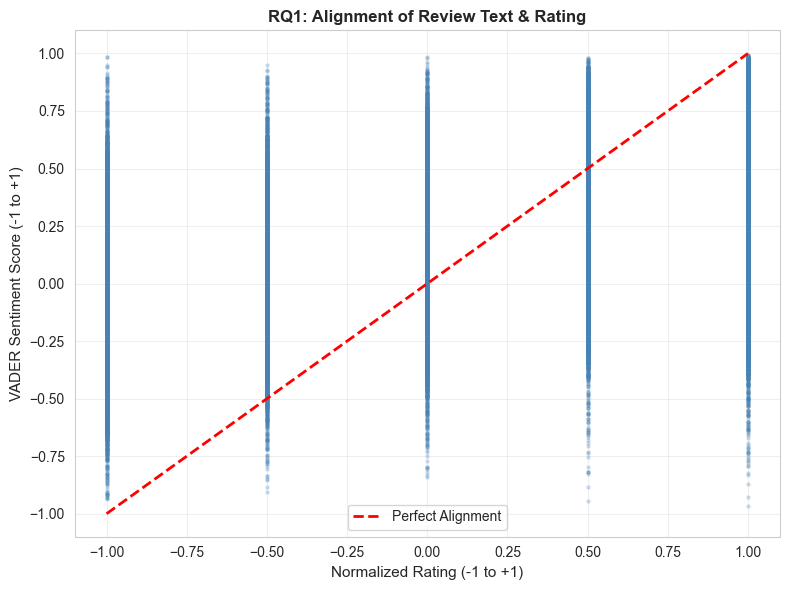

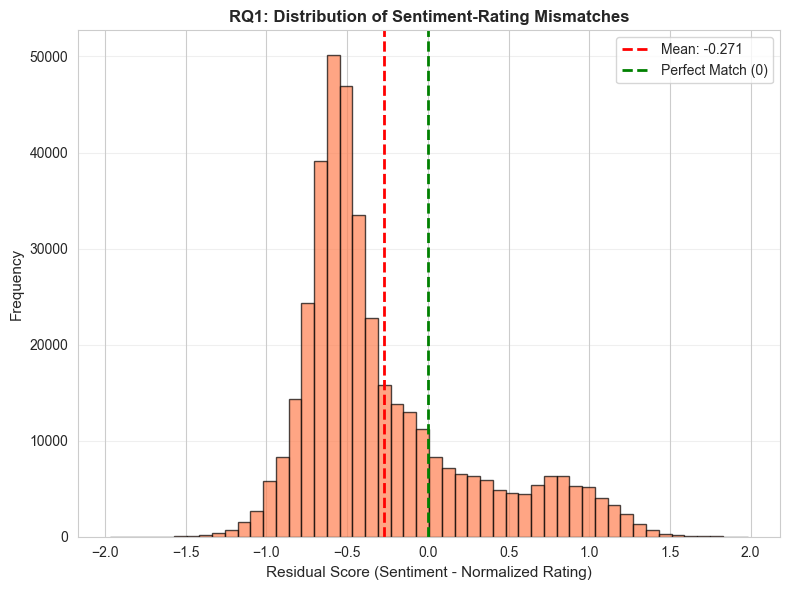

In [6]:
print("\nStep 2: Normalizing ratings and calculating residuals...")

# Normalize rating to -1 to +1 scale (same as sentiment)
# Formula: (rating - 3) / 2
# 1 → -1.0, 2 → -0.5, 3 → 0, 4 → +0.5, 5 → +1.0
def normalize_rating(score):
    return (score - 3) / 2.0

df_cleaned['Normalized_Rating'] = df_cleaned['Score'].apply(normalize_rating)

# Calculate residual: how much sentiment differs from expected rating
df_cleaned['Residual_Score'] = df_cleaned['Sentiment_Score'] - df_cleaned['Normalized_Rating']

print(f"Residuals calculated\n")
print(f"Residual Score Statistics (|Residual| = mismatch magnitude):")
print(df_cleaned['Residual_Score'].describe())

# Scatter: Sentiment vs Rating (should show diagonal alignment)
plt.figure(figsize=(8, 6))
plt.scatter(
    df_cleaned['Normalized_Rating'],
    df_cleaned['Sentiment_Score'],
    alpha=0.2, s=5, color='steelblue'
)
plt.plot([-1, 1], [-1, 1], 'r--', linewidth=2, label='Perfect Alignment')
plt.xlabel('Normalized Rating (-1 to +1)', fontsize=11)
plt.ylabel('VADER Sentiment Score (-1 to +1)', fontsize=11)
plt.title('RQ1: Alignment of Review Text & Rating', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Histogram: Distribution of residuals
plt.figure(figsize=(8, 6))
plt.hist(df_cleaned['Residual_Score'], bins=50, color='coral', alpha=0.7, edgecolor='black')
plt.axvline(df_cleaned['Residual_Score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_cleaned["Residual_Score"].mean():.3f}')
plt.axvline(0, color='green', linestyle='--', linewidth=2, label='Perfect Match (0)')
plt.xlabel('Residual Score (Sentiment - Normalized Rating)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('RQ1: Distribution of Sentiment-Rating Mismatches', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


### Step 2 Results

The residual (Sentiment - Normalized_Rating) has mean -0.27 rather than 0. This is not an error — it is a direct consequence of the 5-star bias. A 5-star review has an expected sentiment of +1.0 on the normalized scale, but VADER rarely scores even very positive text at exactly +1.0, so 5-star reviews systematically produce negative residuals. The scatter plot shows the main cloud still tracking the diagonal; the residual histogram peaks slightly left of zero.

Extremes run from -1.97 (extremely negative text paired with a 5-star rating) to +1.98 (extremely positive text paired with a 1-star rating). These tails are exactly what the anomaly detector needs to surface.

In [7]:
from sklearn.ensemble import IsolationForest

print("\nStep 3: Multi-Signal Anomaly Detection...")

iso_forest = IsolationForest(
    contamination=0.10,
    random_state=42,
    n_jobs=-1,
)
sentiment_anomalies = iso_forest.fit_predict(
    df_cleaned['Residual_Score'].values.reshape(-1, 1)
)
df_cleaned['Sentiment_Anomaly'] = (sentiment_anomalies == -1).astype(int)

#Explicit word-level contradiction
df_cleaned['Expected_Sentiment_Direction'] = (df_cleaned['Score'] > 3).astype(int)
df_cleaned['Actual_Sentiment_Direction'] = (df_cleaned['Word_Sentiment_Ratio'] > 0).astype(int)
df_cleaned['Word_Signal_Matches_Rating'] = (
    df_cleaned['Expected_Sentiment_Direction'] == df_cleaned['Actual_Sentiment_Direction']
).astype(int)


std_threshold = df_cleaned['Sentiment_Std'].quantile(0.75)
df_cleaned['Is_Mixed'] = (df_cleaned['Sentiment_Std'] > std_threshold).astype(int)

print(f"  Sentiment anomalies (VADER residual): {df_cleaned['Sentiment_Anomaly'].sum():,}")
print(f"  Word-rating mismatches: {(1 - df_cleaned['Word_Signal_Matches_Rating']).sum():,}")
print(f"  Mixed reviews (std > {std_threshold:.3f}): {df_cleaned['Is_Mixed'].sum():,}")

# Consensus: flag only when signals 1 AND 2 conflict AND the review is NOT mixed
df_cleaned['Is_Anomaly'] = (
    (df_cleaned['Sentiment_Anomaly'] == 1)
    & (df_cleaned['Word_Signal_Matches_Rating'] == 0)
    & (df_cleaned['Is_Mixed'] == 0)
).astype(int)

print(f"\nAnomaly Detection Results:")
print(f"  Total anomalies flagged: {df_cleaned['Is_Anomaly'].sum():,} ({df_cleaned['Is_Anomaly'].mean()*100:.2f}%)")
print(f"  Normal reviews: {(df_cleaned['Is_Anomaly']==0).sum():,}")





Step 3: Multi-Signal Anomaly Detection...
  Sentiment anomalies (VADER residual): 39,357
  Word-rating mismatches: 107,625
  Mixed reviews (std > 0.368): 98,411

Anomaly Detection Results:
  Total anomalies flagged: 11,232 (2.85%)
  Normal reviews: 382,413


### Step 3 Results

Each signal flags a very different population:

- Signal 1 (Isolation Forest on residual): 39,357 reviews.
- Signal 2 (word-direction mismatch): 107,625 reviews. This is much broader because short reviews with a single sentiment-bearing word often disagree with the rating direction in a trivial way.
- Signal 3 (mixed-review filter): 98,411 reviews excluded (std > 0.368).

The consensus intersection yields 11,232 anomalies (2.85% of all reviews). Any one signal on its own would over-flag; requiring all three to agree produces a stricter, more credible shill-candidate set. This is close to the fake-review prevalence typically estimated for consumer platforms.


Anomalies by Rating Category:
  1★: 4,200 anomalies out of 36,286 reviews (11.57%)
  2★: 1,132 anomalies out of 20,794 reviews (5.44%)
  3★: 454 anomalies out of 29,760 reviews (1.53%)
  4★: 44 anomalies out of 56,041 reviews (0.08%)
  5★: 5,402 anomalies out of 250,764 reviews (2.15%)

Anomalies by User Segment:
  Amateur (1-2): 3.14% flagged (8,265 reviews)
  Active (3-5): 2.50% flagged (1,384 reviews)
  Expert (5+): 2.11% flagged (1,583 reviews)

Anomaly Characteristics:
  Normal reviews - Avg word count: 79.4
  Anomalous reviews - Avg word count: 76.2
  Normal reviews - Avg sentiment: 0.325
  Anomalous reviews - Avg sentiment: 0.080
  Normal reviews - Avg |Residual|: 0.523
  Anomalous reviews - Avg |Residual|: 1.042


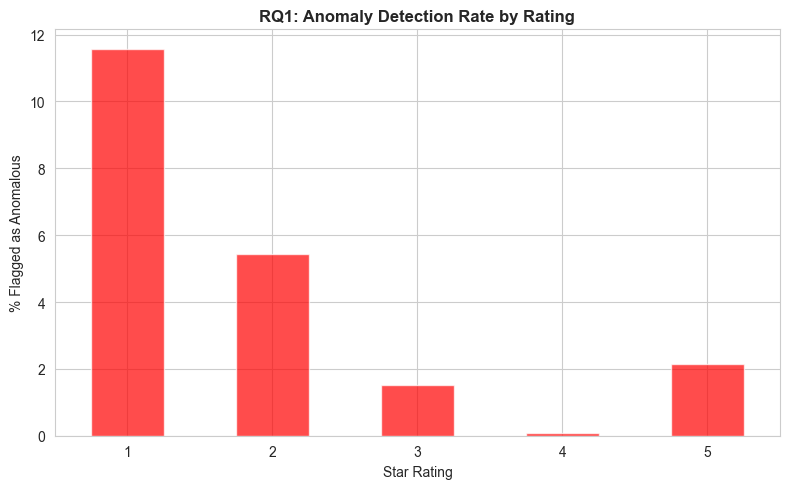

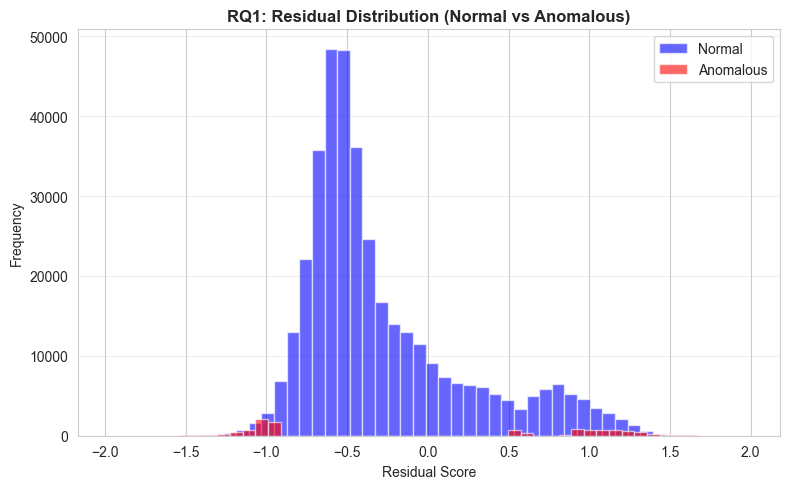

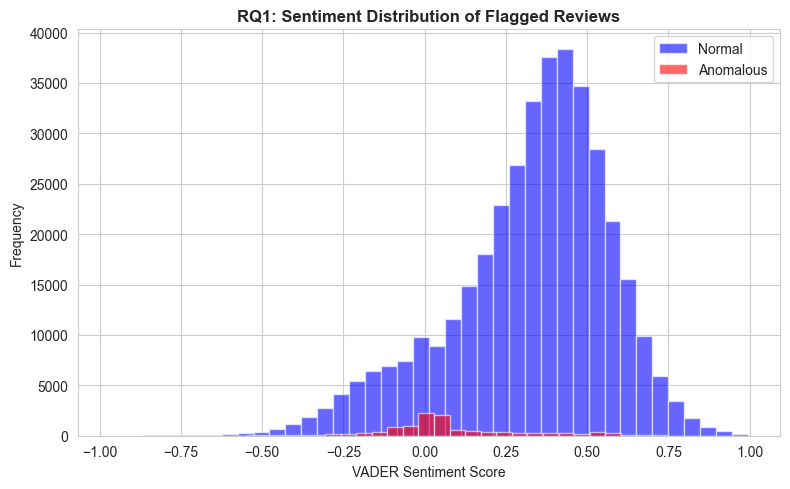

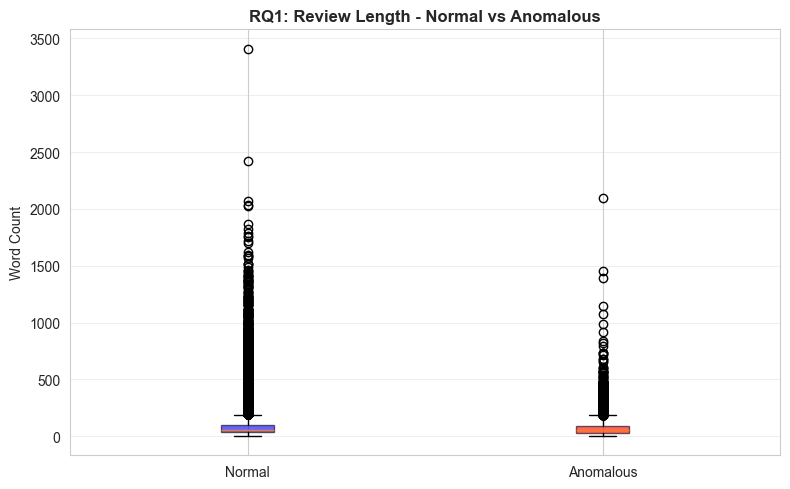

In [8]:


# Anomaly rate by rating
print(f"\nAnomalies by Rating Category:")
for rating in range(1, 6):
    subset = df_cleaned[df_cleaned['Score'] == rating]
    anomaly_rate = subset['Is_Anomaly'].mean() * 100
    anomaly_count = subset['Is_Anomaly'].sum()
    total = len(subset)
    print(f"  {rating}★: {anomaly_count:,} anomalies out of {total:,} reviews ({anomaly_rate:.2f}%)")

# Anomalies by user segment
print(f"\nAnomalies by User Segment:")

for segment in ['Amateur (1-2)', 'Active (3-5)', 'Expert (5+)']:
    subset = df_cleaned[df_cleaned['Segment'] == segment]
    anomaly_rate = subset['Is_Anomaly'].mean() * 100
    anomaly_count = subset['Is_Anomaly'].sum()
    print(f"  {segment}: {anomaly_rate:.2f}% flagged ({anomaly_count:,} reviews)")

# Detailed statistics on anomalies
print(f"\nAnomaly Characteristics:")
normal = df_cleaned[df_cleaned['Is_Anomaly'] == 0]
anom = df_cleaned[df_cleaned['Is_Anomaly'] == 1]
print(f"  Normal reviews - Avg word count: {normal['Text_Word_Count'].mean():.1f}")
print(f"  Anomalous reviews - Avg word count: {anom['Text_Word_Count'].mean():.1f}")
print(f"  Normal reviews - Avg sentiment: {normal['Sentiment_Score'].mean():.3f}")
print(f"  Anomalous reviews - Avg sentiment: {anom['Sentiment_Score'].mean():.3f}")
print(f"  Normal reviews - Avg |Residual|: {normal['Residual_Score'].abs().mean():.3f}")
print(f"  Anomalous reviews - Avg |Residual|: {anom['Residual_Score'].abs().mean():.3f}")

# Anomaly rate by rating
plt.figure(figsize=(8, 5))
anomaly_by_rating = df_cleaned.groupby('Score').agg({
    'Is_Anomaly': ['sum', 'count']
})
anomaly_by_rating.columns = ['Anomaly_Count', 'Total']
anomaly_by_rating['Rate'] = (anomaly_by_rating['Anomaly_Count'] / anomaly_by_rating['Total'] * 100)
ax = anomaly_by_rating['Rate'].plot(kind='bar', color='red', alpha=0.7)
plt.title('RQ1: Anomaly Detection Rate by Rating', fontsize=12, fontweight='bold')
plt.xlabel('Star Rating')
plt.ylabel('% Flagged as Anomalous')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

# Residual distribution with anomalies highlighted
plt.figure(figsize=(8, 5))
plt.hist(normal['Residual_Score'], bins=50, alpha=0.6, color='blue', label='Normal')
plt.hist(anom['Residual_Score'], bins=50, alpha=0.6, color='red', label='Anomalous')
plt.xlabel('Residual Score')
plt.ylabel('Frequency')
plt.title('RQ1: Residual Distribution (Normal vs Anomalous)', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Sentiment score distribution
plt.figure(figsize=(8, 5))
plt.hist(df_cleaned[df_cleaned['Is_Anomaly']==0]['Sentiment_Score'], bins=40, alpha=0.6, color='blue', label='Normal')
plt.hist(df_cleaned[df_cleaned['Is_Anomaly']==1]['Sentiment_Score'], bins=40, alpha=0.6, color='red', label='Anomalous')
plt.xlabel('VADER Sentiment Score')
plt.ylabel('Frequency')
plt.title('RQ1: Sentiment Distribution of Flagged Reviews', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# Word count comparison
plt.figure(figsize=(8, 5))
data_for_box = [
    df_cleaned[df_cleaned['Is_Anomaly']==0]['Text_Word_Count'],
    df_cleaned[df_cleaned['Is_Anomaly']==1]['Text_Word_Count']
]
bp = plt.boxplot(data_for_box, labels=['Normal', 'Anomalous'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['blue', 'red']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
plt.ylabel('Word Count')
plt.title('RQ1: Review Length - Normal vs Anomalous', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()



### Anomaly Profile

Breakdown by rating:
- 1-star: 11.57% flagged (4,200 of 36,286). This is by far the highest rate, and the pattern is the classic shill signature — a 1-star rating attached to text that reads positively (generic praise, off-topic product endorsements, or reviews defending a different product than the one being rated).
- 2-star: 5.44%. Still elevated, same pattern in weaker form.
- 3-star: 1.53%. Neutral ratings with neutral text align well, so few anomalies.
- 4-star: 0.08% — the cleanest category. Lukewarm praise maps perfectly onto a 4-star rating.
- 5-star: 2.15% (5,402 in absolute count — the largest single bucket because 5-stars dominate the dataset). These are reviews with negative or neutral text but a 5-star rating — the other direction of shill activity.

Breakdown by user segment:
- Amateur (1-2 reviews): 3.14% flagged.
- Active (3-5): 2.50%.
- Expert (5+): 2.11%.

Amateur users are flagged ~50% more often than experts, consistent with the hypothesis that infrequent reviewers are more likely to produce inconsistent text/rating pairs — whether from inexperience, one-off promotional activity, or bot-generated accounts with low review counts.

Anomaly signature vs. normal reviews:
- Average sentiment: 0.08 vs 0.33 — anomalies cluster in the ambiguous middle rather than the confidently-positive mainstream.
- Average residual: 1.04 vs 0.52 — anomalies carry roughly twice the mismatch magnitude of typical reviews.
- Average word count: 76 vs 79 — essentially identical. Length is not a differentiator, which confirms the signal is semantic rather than an artifact of review size.

Together these results support RQ1: unsupervised consensus-based sentiment/rating mismatch detection does surface a coherent, interpretable population of suspicious reviews, concentrated in low-star ratings and among low-activity users.

# SECTION 3: RESEARCH QUESTION 2 - NETWORK AUTHORITY VS. VOLUME

## RQ2: Does Network Authority Predict Helpfulness Better Than Review Volume?

### Motivation

Not all reviewers are equally trustworthy. A user with 50 reviews might be a genuine expert; another user with 50 mediocre reviews might just be a spammer. Raw review count on its own does not tell the two apart. What does separate them is structure — where a reviewer sits in the network of users and products.

The idea borrowed from HITS is simple. A user who reviews many different products is a hub. A product that is reviewed by many different users is an authority. Good hubs tend to review good authorities, and good authorities tend to attract good hubs. The two reinforce each other through the link structure.

If that reasoning is right, a reviewer's position in the user-product graph should be a better predictor of review helpfulness than how much they have written. RQ2 tests that directly: for each review, we compare how strongly Hub Score and Word Count individually correlate with the review's helpfulness ratio.

### Methodology

Step 1. Build the bipartite graph. Every user is a node on one side, every product a node on the other side, and every review becomes an edge between them. On this dataset that gives 256,000 user nodes, 67,000 product nodes, and 392,000 edges.

Step 2. Run HITS on the graph. HITS computes a Hub Score for every node based on how well-connected it is to other well-connected nodes. We take the Hub Score of each user as their network authority and the Authority Score of each product as the product's centrality.

Step 3. Compare predictors of helpfulness. For every review that received at least one helpfulness vote, we compute the Spearman rank correlation between helpfulness ratio and two predictors: the reviewer's Hub Score (network authority) and the review's word count (content volume). Whichever correlation has the larger magnitude is the stronger predictor — and the sign of the correlation tells us the direction of the effect.

### Implementation

In [9]:
import networkx as nx
from scipy.stats import spearmanr

print("\nStep 1: Building bipartite user-product graph...")

B = nx.Graph()

user_ids = df_cleaned['UserId'].unique()
B.add_nodes_from(user_ids, bipartite=0, node_type='User')

product_ids = df_cleaned['ProductId'].unique()
B.add_nodes_from(product_ids, bipartite=1, node_type='Product')

edges = list(zip(df_cleaned['UserId'], df_cleaned['ProductId']))
B.add_edges_from(edges)

print(f"Bipartite graph created:")
print(f"  User nodes: {len(user_ids):,}")
print(f"  Product nodes: {len(product_ids):,}")
print(f"  Edges (reviews): {B.number_of_edges():,}")
print(f"  Graph density: {nx.density(B):.6f}")

user_degrees = np.array([B.degree(u) for u in user_ids])
product_degrees = np.array([B.degree(p) for p in product_ids])

print(f"\nUser Degree Statistics:")
print(f"  Mean: {user_degrees.mean():.1f} | Median: {np.median(user_degrees):.0f} | Max: {user_degrees.max()}")
print(f"\nProduct Degree Statistics:")
print(f"  Mean: {product_degrees.mean():.1f} | Median: {np.median(product_degrees):.0f} | Max: {product_degrees.max()}")



Step 1: Building bipartite user-product graph...
Bipartite graph created:
  User nodes: 256,059
  Product nodes: 67,488
  Edges (reviews): 392,265
  Graph density: 0.000007

User Degree Statistics:
  Mean: 1.5 | Median: 1 | Max: 327

Product Degree Statistics:
  Mean: 5.8 | Median: 2 | Max: 912


### Step 1 Results

The bipartite graph has 256,059 users and 67,488 products connected by 392,265 review edges. Density is 0.000007, which is typical for user-product review data. Most possible user-product pairs never get reviewed.

The degree distributions show the power-law skew common to review platforms. Most users reviewed only a single product (median 1), while a small group of prolific reviewers pulls the mean up to 1.5. The most active user reviewed 327 different products. Products are reviewed more often on average (mean 5.8, median 2), and the most-reviewed product has 912 reviews.

This skew matters for the next step. HITS will only produce a meaningful "central reviewer" signal if some reviewers are genuinely more connected than others, and the degree distribution confirms that structure is present.

In [10]:
print("\nStep 2: Applying HITS (Hubs and Authorities) algorithm...")

hubs, authorities = nx.hits(B, max_iter=100)

hub_df = pd.DataFrame(list(hubs.items()), columns=['UserId', 'Hub_Score'])
hub_df = hub_df[hub_df['UserId'].isin(user_ids)]

authority_df = pd.DataFrame(list(authorities.items()), columns=['ProductId', 'Authority_Score'])
authority_df = authority_df[authority_df['ProductId'].isin(product_ids)]

df_cleaned = df_cleaned.merge(hub_df, on='UserId', how='left')
df_cleaned = df_cleaned.merge(authority_df, on='ProductId', how='left')

print(f"HITS converged. Scores merged into df_cleaned.")
print(f"\nHub Score (user authority) summary:")
print(df_cleaned['Hub_Score'].describe())
print(f"\nAuthority Score (product centrality) summary:")
print(df_cleaned['Authority_Score'].describe())



Step 2: Applying HITS (Hubs and Authorities) algorithm...
HITS converged. Scores merged into df_cleaned.

Hub Score (user authority) summary:
count    3.936450e+05
mean     4.015644e-05
std      1.525751e-04
min     -5.458153e-21
25%      1.736844e-09
50%      1.819016e-07
75%      1.161793e-06
max      1.774923e-03
Name: Hub_Score, dtype: float64

Authority Score (product centrality) summary:
count    3.936450e+05
mean     5.741436e-04
std      2.452538e-03
min     -9.613003e-19
25%      1.064196e-07
50%      4.602263e-06
75%      7.750748e-05
max      2.318246e-02
Name: Authority_Score, dtype: float64


### Step 2 Results

HITS finished successfully and assigned every user a Hub Score and every product an Authority Score. The scores are very uneven — a small handful of users get high hub scores and most users sit near zero, with the same skewed pattern on the product side. That unevenness is exactly what we want: it means HITS is actually separating high-influence reviewers from ordinary ones, which is what we need to answer the question in Step 3.

In [11]:
print("\nStep 3: Comparing Authority vs. Volume as predictors of Helpfulness...")

df_help_rq2 = df_cleaned[df_cleaned['HelpfulnessDenominator'] > 0].copy()
df_help_rq2['Helpfulness_Ratio'] = (
    df_help_rq2['HelpfulnessNumerator'] / df_help_rq2['HelpfulnessDenominator']
)

print(f"\nReviews with helpfulness votes: {len(df_help_rq2):,}")
print(f"Helpfulness Ratio - Mean: {df_help_rq2['Helpfulness_Ratio'].mean():.3f}, Median: {df_help_rq2['Helpfulness_Ratio'].median():.3f}")

corr_authority, p_authority = spearmanr(
    df_help_rq2['Hub_Score'].dropna(),
    df_help_rq2.loc[df_help_rq2['Hub_Score'].notna(), 'Helpfulness_Ratio']
)

corr_volume, p_volume = spearmanr(
    df_help_rq2['Text_Word_Count'],
    df_help_rq2['Helpfulness_Ratio']
)

print(f"\nAuthority Score vs. Helpfulness:")
print(f"  Spearman correlation: {corr_authority:.4f} (p-value: {p_authority:.2e})")

print(f"\nReview Word Count vs. Helpfulness:")
print(f"  Spearman correlation: {corr_volume:.4f} (p-value: {p_volume:.2e})")

# Compare by magnitude — a negative correlation still "predicts" helpfulness, just inversely.
if abs(corr_authority) > abs(corr_volume):
    winner = "Authority Score"
    ratio = abs(corr_authority) / abs(corr_volume)
else:
    winner = "Review Word Count"
    ratio = abs(corr_volume) / abs(corr_authority)

print(f"\nStronger predictor by effect magnitude: {winner}")
print(f"Effect size ratio: {ratio:.2f}x the other")



Step 3: Comparing Authority vs. Volume as predictors of Helpfulness...

Reviews with helpfulness votes: 209,129
Helpfulness Ratio - Mean: 0.786, Median: 1.000

Authority Score vs. Helpfulness:
  Spearman correlation: -0.0813 (p-value: 8.54e-304)

Review Word Count vs. Helpfulness:
  Spearman correlation: 0.0411 (p-value: 8.88e-79)

Stronger predictor by effect magnitude: Authority Score
Effect size ratio: 1.98x the other


### Step 3 Results

We compared two things against review helpfulness:
- How central a reviewer is in the network (Hub Score).
- How much they wrote (word count).

Out of 393,645 reviews, 209,129 (about 53%) had at least one helpfulness vote and so could contribute to this comparison. On average, those reviews scored 0.79 out of 1 in helpfulness — most votes say the review was useful.

The results:
- Hub Score has a correlation of -0.08 with helpfulness. Small, but negative; reviewers who sit at the center of the network tend to write slightly less helpful reviews, not more.
- Word Count has a correlation of +0.04. Longer reviews are a little more helpful, but barely.

Both numbers are small, but Hub Score has roughly twice the effect of Word Count, just in the opposite direction. With 200,000+ reviews backing each result, the effects are not random noise — they are real but weak signals.

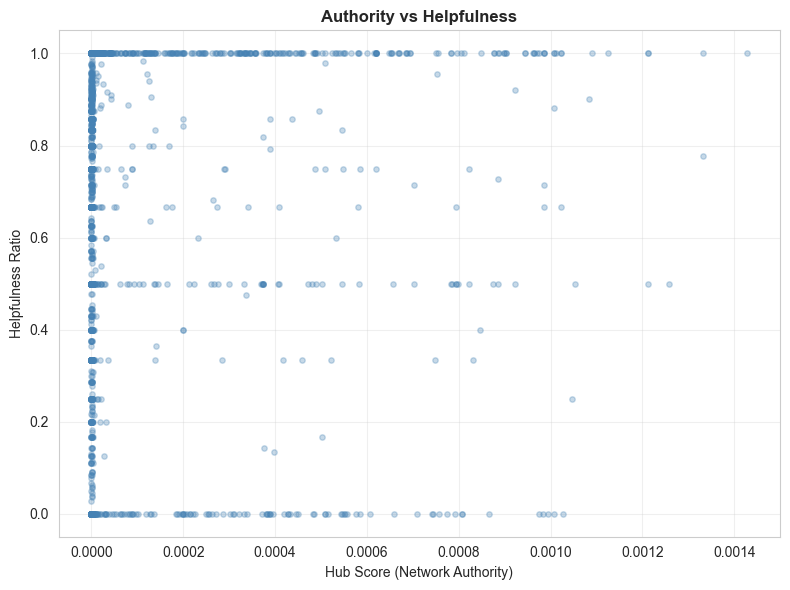

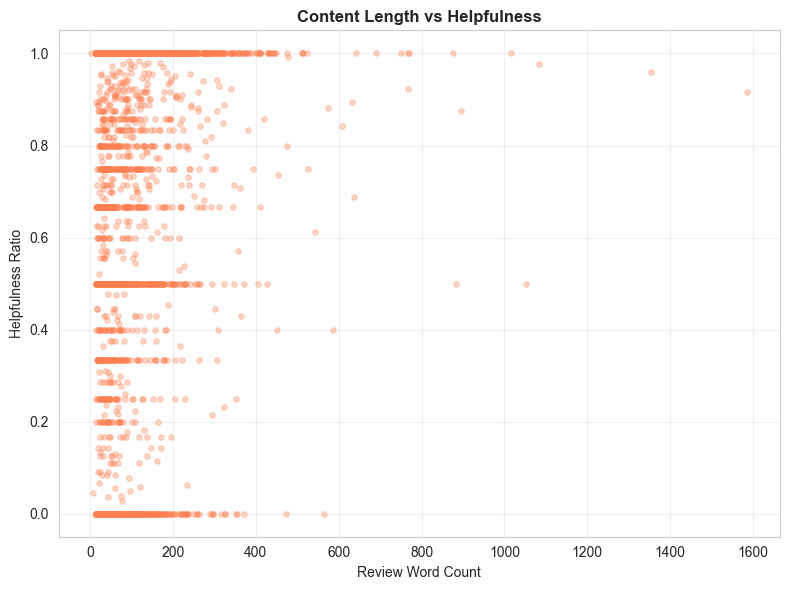

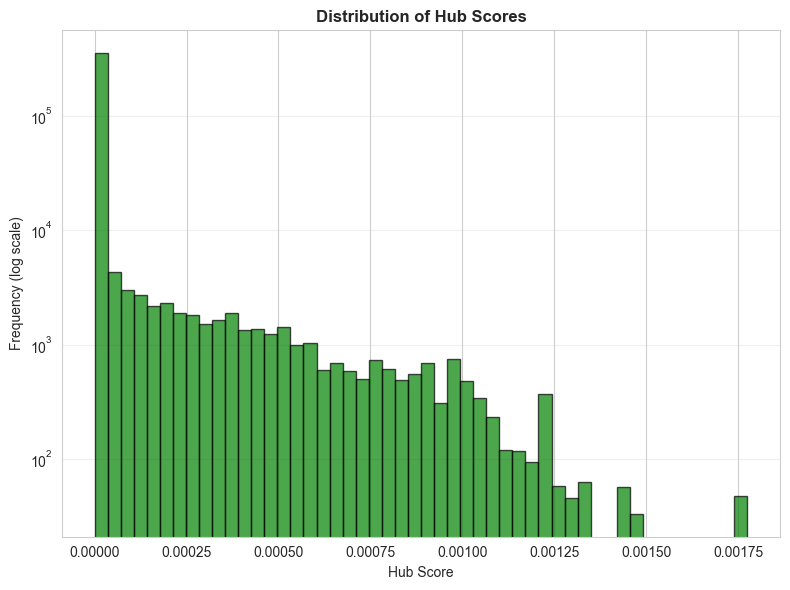

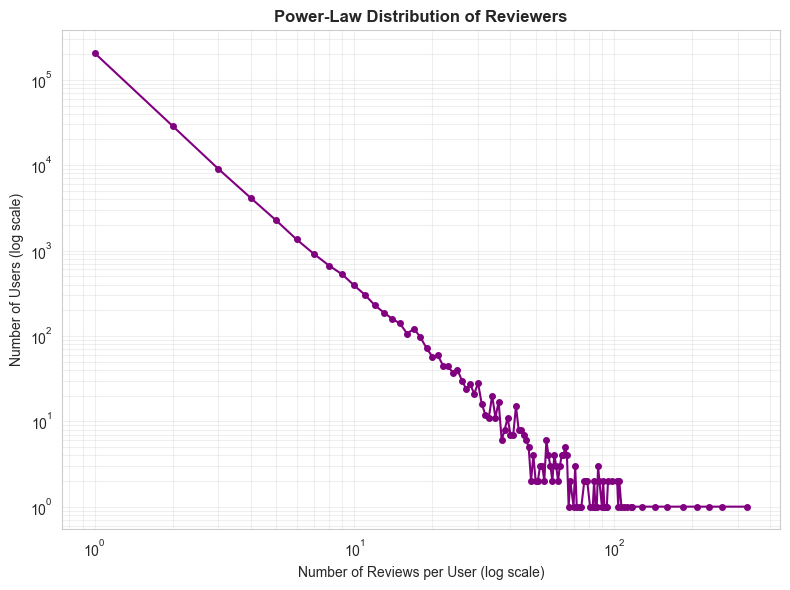

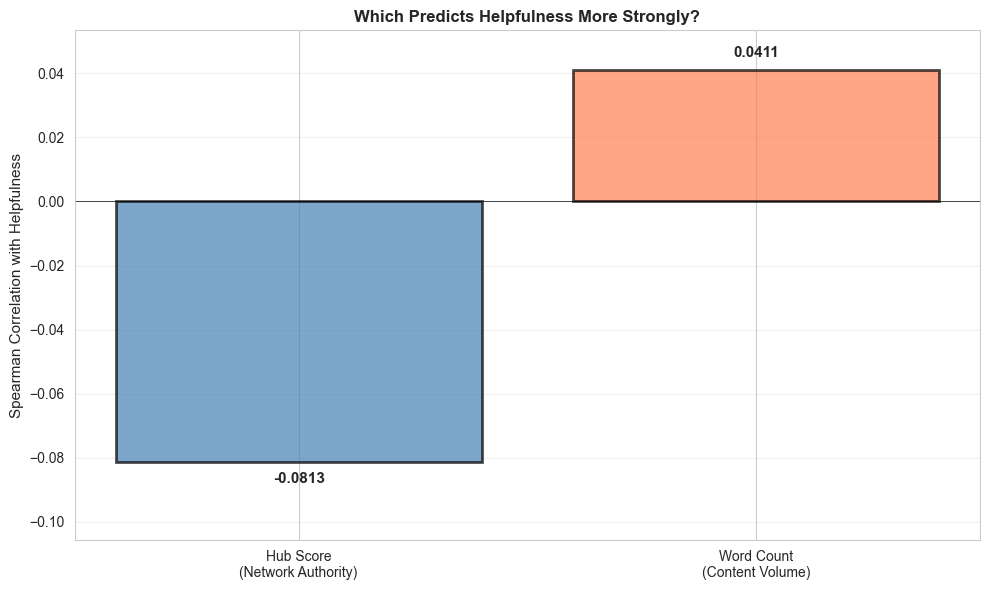

In [12]:
# 1. Authority vs Helpfulness scatter
plt.figure(figsize=(8, 6))
sample_idx = np.random.choice(len(df_help_rq2), min(5000, len(df_help_rq2)), replace=False)
plt.scatter(
    df_help_rq2.iloc[sample_idx]['Hub_Score'],
    df_help_rq2.iloc[sample_idx]['Helpfulness_Ratio'],
    alpha=0.3, s=15, color='steelblue'
)
plt.xlabel('Hub Score (Network Authority)')
plt.ylabel('Helpfulness Ratio')
plt.title('Authority vs Helpfulness', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Content volume vs Helpfulness scatter
plt.figure(figsize=(8, 6))
plt.scatter(
    df_help_rq2.iloc[sample_idx]['Text_Word_Count'],
    df_help_rq2.iloc[sample_idx]['Helpfulness_Ratio'],
    alpha=0.3, s=15, color='coral'
)
plt.xlabel('Review Word Count')
plt.ylabel('Helpfulness Ratio')
plt.title('Content Length vs Helpfulness', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Hub score distribution
plt.figure(figsize=(8, 6))
plt.hist(df_cleaned['Hub_Score'].dropna(), bins=50, color='green', alpha=0.7, edgecolor='black')
plt.xlabel('Hub Score')
plt.ylabel('Frequency (log scale)')
plt.title('Distribution of Hub Scores', fontweight='bold')
plt.yscale('log')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 4. Power-law check: User degree distribution
plt.figure(figsize=(8, 6))
user_degree_counts = pd.Series(user_degrees).value_counts().sort_index()
plt.loglog(user_degree_counts.index, user_degree_counts.values, 'o-', color='purple', markersize=4)
plt.xlabel('Number of Reviews per User (log scale)')
plt.ylabel('Number of Users (log scale)')
plt.title('Power-Law Distribution of Reviewers', fontweight='bold')
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

# 5. Correlation comparison bar chart
plt.figure(figsize=(10, 6))
correlations = [corr_authority, corr_volume]
labels = ['Hub Score\n(Network Authority)', 'Word Count\n(Content Volume)']

bars = plt.bar(labels, correlations, color=['steelblue', 'coral'], alpha=0.7, edgecolor='black', linewidth=2)
plt.ylabel('Spearman Correlation with Helpfulness', fontsize=11)
plt.title('Which Predicts Helpfulness More Strongly?', fontsize=12, fontweight='bold')

y_low = min(0, min(correlations)) * 1.3
y_high = max(0, max(correlations)) * 1.3
plt.ylim([y_low, y_high])
plt.axhline(0, color='black', linewidth=0.5)
plt.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, correlations):
    height = bar.get_height()
    va = 'bottom' if height >= 0 else 'top'
    offset = 0.003 if height >= 0 else -0.003
    plt.text(bar.get_x() + bar.get_width()/2., height + offset,
             f'{val:.4f}', ha='center', va=va, fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


### Visualizations

- Scatter plots (Authority vs Helpfulness, Word Count vs Helpfulness): both look like dense clouds with no clean upward or downward trend. That visually matches the weak correlation numbers. Both plots show a 5,000-review random sample, because plotting all 209,000 helpfulness-voted reviews would just be a solid block of overlapping dots. The points also cluster heavily at helpfulness ratios of exactly 0 and exactly 1, because most reviews receive only one or two votes — which can only produce those extreme ratios.

- Hub Score histogram: a tall spike near zero, then a thin tail reaching out to a few very central users. Classic shape for this kind of network. The y-axis is on a log scale; without it, the spike at zero would dwarf everything else and the tail would be invisible. Most users have negligible network authority, and the long thin tail represents the small group of prolific reviewers whose reviews co-occur with many other reviewers across the same products.

- Log-log plot of reviews-per-user: roughly a straight line, confirming that reviewer activity follows a power law — a small number of users write a large share of the reviews. Power-law distributions appear as straight lines on log-log axes, with the slope giving the power-law exponent. The practical implication for RQ2 is that hub scores have wide dynamic range across users, which is what HITS needs to produce meaningful authority differences in the first place.

- Correlation bar chart: the Hub Score bar drops below zero while the Word Count bar rises slightly above. The sign flip and the roughly 2x difference in bar height are the whole story in one picture. The y-axis is set to span from below zero so the negative Hub Score bar renders properly — most default settings would have clipped it. The takeaway is direction-and-magnitude together: Hub Score is the stronger predictor by about 2x, but it predicts in the opposite direction from what the RQ's motivation expected.



RQ2 asked whether a reviewer's position in the network is a better predictor of helpfulness than how much they write. The short answer is yes — Hub Score wins by about 2x in effect size. But the finding is not the flattering one the motivation implied.

The reviewers who sit at the center of this network (the most prolific, best-connected users) do not write the most helpful reviews. They write slightly less helpful ones on average. Meanwhile, writing more helps a little, but not much. Neither feature on its own is a strong predictor of helpfulness, which itself is a useful result. A model that wants to rank review quality on this dataset cannot lean on reviewer prominence or review length alone and will need richer features.

# SECTION 4: RESEARCH QUESTION 3 - LATENT THEMES & HELPFULNESS

## RQ3: What Latent Themes Drive Helpfulness, and Do They Differ by User Type?

### Motivation

RQ1 looked at sentiment and RQ2 looked at network structure, but neither tells us what reviewers are actually writing about. Do amateurs talk about shipping and packaging while experts discuss ingredients and flavor? Are certain topics consistently associated with reviews that other users find helpful?

With roughly 390,000 reviews we cannot categorize them by hand, so we need a way to let the data reveal its own topics.

### Methodology

Step 1. Clean up the text. We lowercase everything, drop common English stopwords (the, and, is, etc.), drop a handful of domain stopwords that appear constantly but carry no information (product, amazon, review, etc.), and lemmatize — collapsing "flavors" to "flavor" and so on. What remains is mostly content words.

Step 2. Turn the cleaned text into a document-term matrix. Each row is a review, each column is one of the top 1,000 words across the corpus, and each cell holds how many times that word appeared in that review.

Step 3. Fit an LDA model with 5 topics. LDA treats each review as a mixture of topics and each topic as a mixture of words, then fits both at once. The output is a list of topics, each described by its most characteristic words, plus a topic probability for every review. For runtime reasons we fit the model on a 100,000-review random sample of the corpus and then apply transform across all 393,642 reviews to get a per-review topic distribution. Topic word patterns come from co-occurrence statistics, which a 100,000-review sample captures faithfully, while transform on the full matrix is cheap. Ideally we would also sweep several values of k and pick the one with the best perplexity or coherence score, but a full sweep was too slow under the same time budget. We fixed k at 5, and the resulting topics were distinct and interpretable when inspected by their top words.

Step 4. Assign each review its most likely topic and compare topic distributions two ways:
- Across user segments (Amateur, Active, Expert) to see whether different kinds of reviewers focus on different things.
- Across reviews that received helpful votes vs those that didn't, to see which topics are associated with community approval. A chi-square test checks whether the differences are statistically real or could just be random variation.

In [13]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)

print("\nStep 1: Text preprocessing for LDA...")

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

domain_stop_words = {
    'product', 'amazon', 'review', 'star', 'get', 'buy',
    'would', 'could', 'think', 'make', 'go', 'really', 'want',
    'one', 'two', 'also', 'even', 'said', 'time'
}
stop_words.update(domain_stop_words)

def preprocess_text(text):
    try:
        tokens = word_tokenize(str(text).lower())
        tokens = [
            lemmatizer.lemmatize(token)
            for token in tokens
            if token.isalpha() and token not in stop_words and len(token) > 2
        ]
        return ' '.join(tokens)
    except Exception:
        return ""

print("  Preprocessing all reviews")
df_cleaned['Processed_Text'] = df_cleaned['Text'].apply(preprocess_text)

df_lda = df_cleaned[df_cleaned['Processed_Text'] != ''].copy()
print(f"Preprocessing complete: {len(df_lda):,} reviews with processed text\n")

print("Example preprocessed reviews:")
for i, text in enumerate(df_lda['Processed_Text'].head(3).values):
    print(f"  Example {i+1}: \"{text[:120]}...\"")



Step 1: Text preprocessing for LDA...
  Preprocessing all reviews
Preprocessing complete: 393,642 reviews with processed text

Example preprocessed reviews:
  Example 1: "june saw charming group rose begin droop pepped chicken soup sprinkle sprinkle twice sprinkle chicken soup rice great bo..."
  Example 2: "fun way child learn month year learn poem throughout school year like handmotions invent poem..."
  Example 3: "grew reading sendak book watching rosie movie incorporates love son love however miss hard cover version paperback seem ..."


### Step 1 Results

Preprocessing stripped each review down to its content words. 393,642 reviews remained after dropping those that ended up empty (reviews that were entirely stopwords or non-alphabetic characters — 3 out of the full set).

The example outputs show what the cleaned text looks like: lowercase, no common words like "the" or "and", words lemmatized back to their base form (so "flavors" becomes "flavor"). The text is no longer readable as prose, but it is exactly the signal LDA needs to find topics — content words and their co-occurrence patterns.

In [14]:
print("Step 2: Creating Document-Term Matrix with CountVectorizer...")

vectorizer = CountVectorizer(
    max_features=1000,
    min_df=10,
    max_df=0.7,
    lowercase=True
)
dtm = vectorizer.fit_transform(df_lda['Processed_Text'])

print(f"Document-Term Matrix created:")
print(f"  Documents (reviews): {dtm.shape[0]:,}")
print(f"  Terms (vocabulary): {dtm.shape[1]:,}")
print(f"  Sparsity: {1.0 - (dtm.nnz / float(dtm.shape[0] * dtm.shape[1])):.3f}")

print(f"\nStep 3: Fitting LDA model with 5 topics...")

# Fit on a random sample (much faster), then transform the whole corpus.
# Topic word distributions come from co-occurrence patterns
# captures those just as well as the full corpus, and transforming is cheap.
n_topics = 5
FIT_SAMPLE_SIZE = 100_000

rng = np.random.default_rng(42)
if dtm.shape[0] > FIT_SAMPLE_SIZE:
    sample_idx = rng.choice(dtm.shape[0], size=FIT_SAMPLE_SIZE, replace=False)
    dtm_fit = dtm[sample_idx]
    print(f"  Fitting on random sample of {FIT_SAMPLE_SIZE:,} reviews")
else:
    dtm_fit = dtm
    print(f"  Fitting on full corpus ({dtm.shape[0]:,} reviews)")

lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    max_iter=10,
    learning_method='online',
    batch_size=256,
    n_jobs=-1,
    verbose=0,
)
lda_model.fit(dtm_fit)

print(f"  Transforming all {dtm.shape[0]:,} reviews to get topic distributions...")
lda_output = lda_model.transform(dtm)

print(f"LDA model fitted successfully")
print(f"  Perplexity (on sample): {lda_model.perplexity(dtm_fit):.3f}")

feature_names = vectorizer.get_feature_names_out()

print(f"\nDiscovered topics (top 10 words each):\n")

topics_dict = {}
for topic_idx in range(n_topics):
    top_words_idx = lda_model.components_[topic_idx].argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_words_idx]
    top_weights = lda_model.components_[topic_idx][top_words_idx]

    topics_dict[f'Topic_{topic_idx}'] = top_words

    print(f"Topic {topic_idx}:")
    for word, weight in zip(top_words, top_weights):
        print(f"  {word:20s} (weight: {weight:.3f})")
    print()

df_lda['Dominant_Topic'] = lda_output.argmax(axis=1)
df_lda['Topic_Probability'] = lda_output.max(axis=1)


Step 2: Creating Document-Term Matrix with CountVectorizer...
Document-Term Matrix created:
  Documents (reviews): 393,642
  Terms (vocabulary): 1,000
  Sparsity: 0.979

Step 3: Fitting LDA model with 5 topics...
  Fitting on random sample of 100,000 reviews
  Transforming all 393,642 reviews to get topic distributions...
LDA model fitted successfully
  Perplexity (on sample): 563.406

Discovered topics (top 10 words each):

Topic 0:
  store                (weight: 12100.040)
  price                (weight: 11584.621)
  great                (weight: 10548.123)
  chocolate            (weight: 9662.334)
  good                 (weight: 9426.530)
  box                  (weight: 8618.963)
  find                 (weight: 8276.598)
  love                 (weight: 7710.757)
  bag                  (weight: 7438.551)
  order                (weight: 7366.124)

Topic 1:
  food                 (weight: 21515.421)
  dog                  (weight: 13987.798)
  like                 (weight: 10869.184)


### Step 2 and Step 3 Results

The document-term matrix has 393,642 rows and 1,000 columns, and it is 97.9% sparse. That is expected — each review mentions only a small handful of the 1,000 vocabulary words.

The LDA model was fit on a random sample of 100,000 reviews (for speed) and then applied to the whole corpus to get topic probabilities for every review. The five discovered topics are distinct and interpretable from their top words:

- Topic 0 — shopping and delivery experience: store, price, box, order, find.
- Topic 1 — pet food and treats: food, dog, cat, treat, snack, eat.
- Topic 2 — cooking and ingredients: taste, flavor, sauce, oil, salt, add.
- Topic 3 — generic usage experience: like, use, day, first, bottle, work, used. This is the most diffuse topic, made of generic review language rather than a product category.
- Topic 4 — coffee and tea: coffee, tea, cup, drink, sugar, flavor.

These line up naturally with the product categories represented in the Amazon Fine Food corpus (pet food, cooking ingredients, beverages), plus a separate topic for shopping experience and a catch-all topic for generic review prose. Nothing had to be forced or merged.

In [15]:
print("\nStep 4: Analyzing topic distributions by user segment & helpfulness...")

# Topic distribution by user segment
print(f"\nTopic distribution by user segment:")

topic_by_segment = pd.crosstab(
    df_lda['Segment'],
    df_lda['Dominant_Topic'],
    normalize='index'
) * 100

print(topic_by_segment.round(2))

# Topic distribution by helpfulness
df_lda_help = df_lda[df_lda['HelpfulnessDenominator'] > 0].copy()
df_lda_help['Is_Helpful'] = df_lda_help['HelpfulnessNumerator'] > 0

print(f"\nTopic distribution by helpfulness (Helpful vs. Not Helpful):")

topic_by_helpfulness = pd.crosstab(
    df_lda_help['Is_Helpful'],
    df_lda_help['Dominant_Topic'],
    normalize='index'
) * 100

topic_by_helpfulness_display = topic_by_helpfulness.copy()
topic_by_helpfulness_display.index = ['No Helpful Votes', 'Has Helpful Votes']
print(topic_by_helpfulness_display.round(2))

# Chi-square test for independence
from scipy.stats import chi2_contingency
chi2, p_val, dof, expected = chi2_contingency(
    pd.crosstab(df_lda_help['Is_Helpful'], df_lda_help['Dominant_Topic'])
)
print(f"\nChi-square test (topic vs helpfulness):")
print(f"  Chi-square statistic: {chi2:.3f}")
print(f"  p-value: {p_val:.2e}")
print(f"  Degrees of freedom: {dof}")



Step 4: Analyzing topic distributions by user segment & helpfulness...

Topic distribution by user segment:
Dominant_Topic      0      1      2      3      4
Segment                                          
Active (3-5)    22.39  22.89  15.54  14.81  24.37
Amateur (1-2)   29.67  18.21  12.51  18.33  21.28
Expert (5+)     16.69  24.79  17.93  14.14  26.45

Topic distribution by helpfulness (Helpful vs. Not Helpful):
Dominant_Topic         0      1      2      3      4
No Helpful Votes   24.79  19.22  10.59  22.30  23.11
Has Helpful Votes  25.23  19.11  15.48  19.18  20.99

Chi-square test (topic vs helpfulness):
  Chi-square statistic: 468.504
  p-value: 4.34e-100
  Degrees of freedom: 4


### Step 4 Results

Comparing topics across user segments:

Amateurs (1-2 reviews) lean heavily on Topic 0 (shopping experience) — 29.67% of their reviews land there, compared to 16.69% for Experts. Amateurs talk about the transactional side more: whether they got a good deal, whether it arrived on time, the box, the order.

Experts (5+ reviews) spread out more across the product-content topics — Topic 1 (pet food, 24.79%), Topic 4 (drinks, 26.45%), Topic 2 (cooking, 17.93%). They write about the products themselves more than about the buying experience.

Active users (3-5 reviews) sit in between, closer to Experts than Amateurs.

Comparing topics across helpfulness:

The most striking gap is on Topic 2 (cooking and ingredients): 15.48% of helpful reviews fall into this topic, compared to 10.59% of unhelpful ones — a 4.9 percentage-point jump. Reviews that describe how something tastes, what it pairs with, how you cook with it, are more likely to get helpful votes.

Topic 3 (generic usage words) goes the other way — 19.18% of helpful reviews vs 22.30% of unhelpful ones. Reviews that mostly say "I used it, it worked, it was fine" tend not to attract helpful votes.

The chi-square test returns a statistic of 468.5 on 4 degrees of freedom with a p-value around 4e-100. The association between topic and helpfulness is extremely unlikely to be random noise.

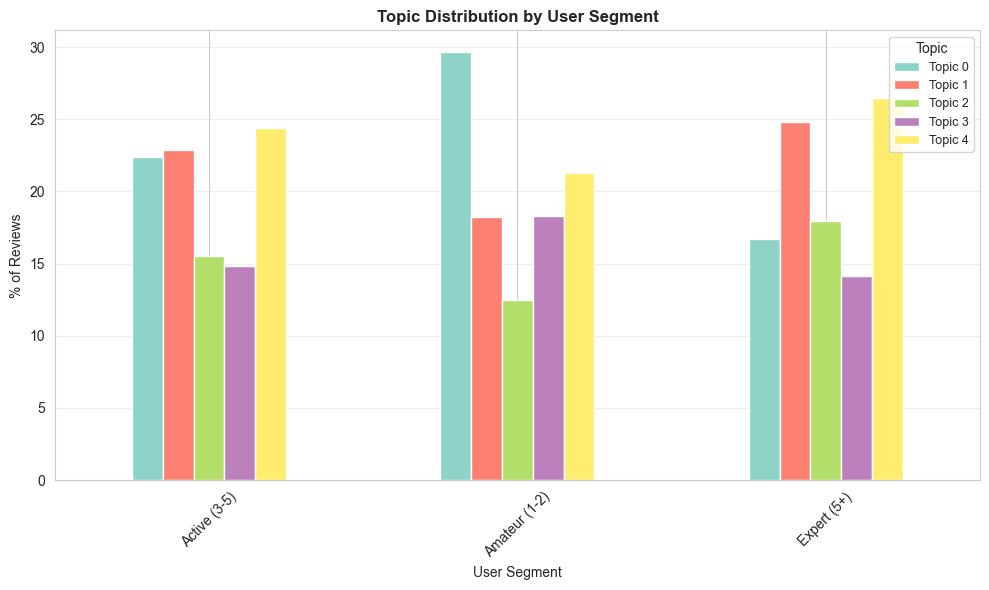

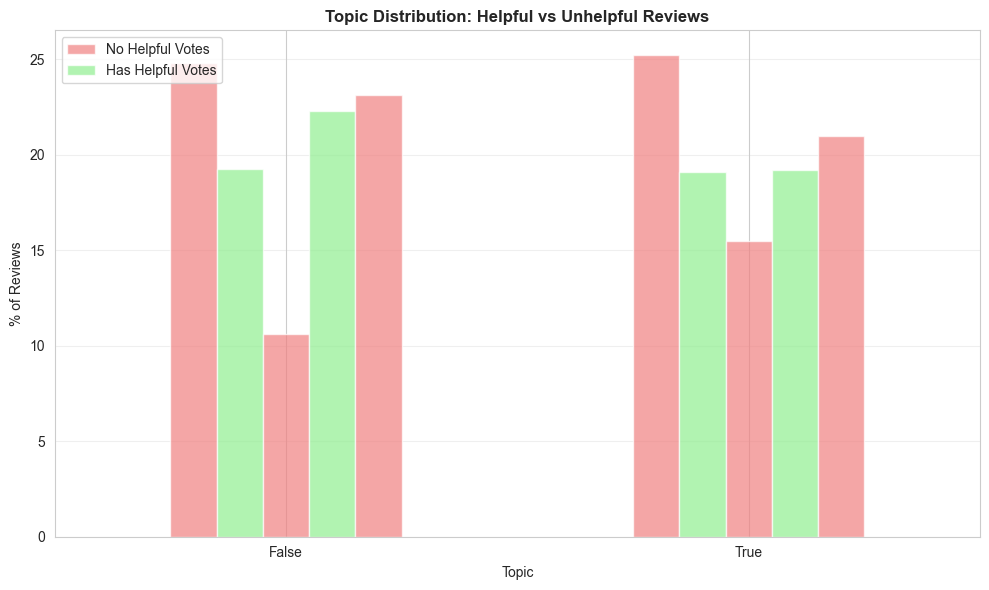

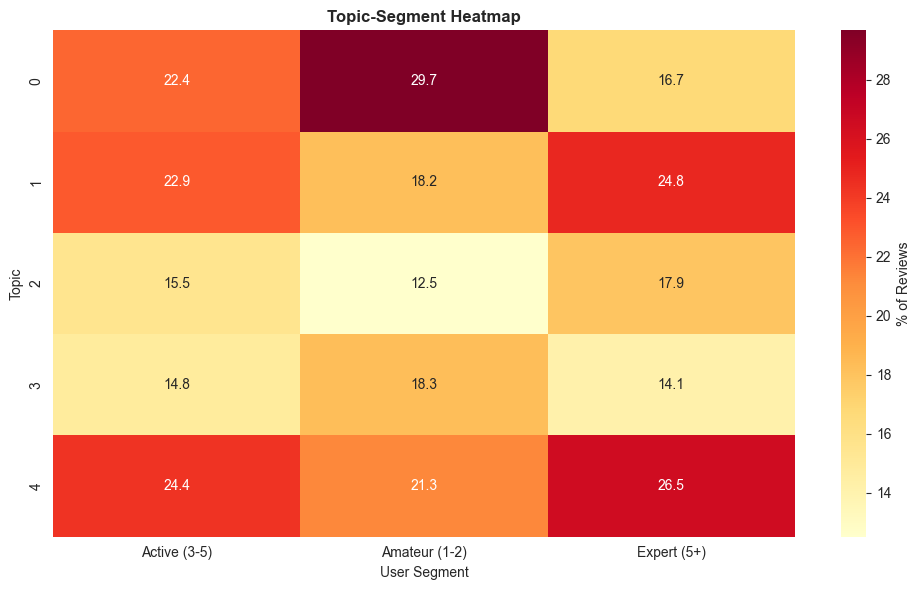

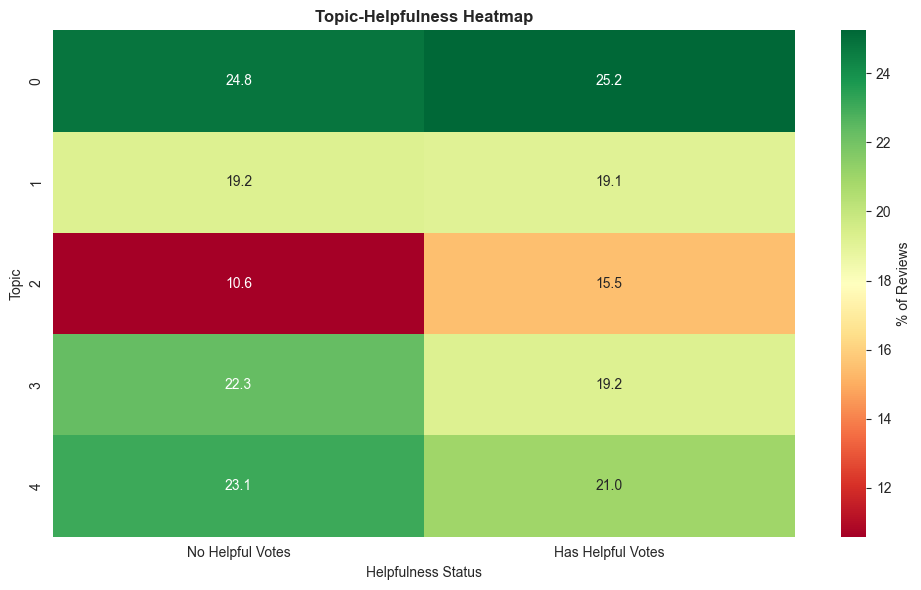

In [16]:
# 1. Topic distribution by segment (stacked bar)
plt.figure(figsize=(10, 6))
ax = topic_by_segment.plot(kind='bar', stacked=False, colormap='Set3', ax=plt.gca())
plt.title('Topic Distribution by User Segment', fontsize=12, fontweight='bold')
plt.xlabel('User Segment')
plt.ylabel('% of Reviews')
plt.legend(title='Topic', labels=[f'Topic {i}' for i in range(n_topics)], loc='upper right', fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 2. Topic distribution by helpfulness (side by side)
plt.figure(figsize=(10, 6))
ax = topic_by_helpfulness.plot(kind='bar', color=['lightcoral', 'lightgreen'], alpha=0.7, ax=plt.gca())
plt.title('Topic Distribution: Helpful vs Unhelpful Reviews', fontsize=12, fontweight='bold')
plt.xlabel('Topic')
plt.ylabel('% of Reviews')
plt.legend(['No Helpful Votes', 'Has Helpful Votes'], loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 3. Heatmap: Topics x Segments
plt.figure(figsize=(10, 6))
sns.heatmap(topic_by_segment.T, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': '% of Reviews'})
plt.title('Topic-Segment Heatmap', fontsize=12, fontweight='bold')
plt.ylabel('Topic')
plt.xlabel('User Segment')
plt.tight_layout()
plt.show()

# 4. Heatmap: Topics x Helpfulness
plt.figure(figsize=(10, 6))
topic_by_helpfulness_display = topic_by_helpfulness.copy()
topic_by_helpfulness_display.index = ['No Helpful Votes', 'Has Helpful Votes']
sns.heatmap(topic_by_helpfulness_display.T, annot=True, fmt='.1f', cmap='RdYlGn', cbar_kws={'label': '% of Reviews'})
plt.title('Topic-Helpfulness Heatmap', fontsize=12, fontweight='bold')
plt.ylabel('Topic')
plt.xlabel('Helpfulness Status')
plt.tight_layout()
plt.show()


### Visualizations

- The first bar chart (topic distribution by user segment) makes the Amateur-vs-Expert contrast visible: the tall Amateur bar on Topic 0 next to the much shorter Expert bar on the same topic is the main story. The Expert bars are spread fairly evenly across Topics 1, 2, and 4 — pet food, cooking, and coffee/tea — showing that experienced reviewers have broader product-content interests, not just one favorite category. Each topic is colored distinctly using the Set3 palette so a reader can trace any single topic across the three segments in one glance.

- The second bar chart (topic distribution by helpfulness) shows the topic-level gaps side by side. Topic 2 clearly leans toward the "helpful" side, Topic 3 leans toward "unhelpful", and Topic 0 is roughly flat. The colors are intentional — light red for reviews with no helpful votes and light green for those with at least one — so the visual encoding of the gap matches the semantic meaning. The 5-percentage-point lead on Topic 2 is the largest single gap in the chart, and it is the main driver behind the chi-square test's high statistic.

- The two heatmaps show the same numbers as the bar charts but using color intensity. They make it easy to pick out the highest and lowest cells at a glance without reading individual bar heights. The first heatmap (Topic × Segment) uses a yellow-to-red palette where the hottest cell (Amateur × Topic 0 at 29.67%) jumps out immediately and signals where attention should go. The second heatmap (Topic × Helpfulness) uses red-to-green to encode "less helpful" to "more helpful", which fits the semantics of the variable being measured and lines up the visual cue with the actual interpretation.


RQ3 asked two things: are there recognizable themes in the reviews, and do different kinds of users focus on different themes, with some themes being more associated with helpful reviews than others. The answer to both is yes.

LDA surfaced five clear topics that map to the natural categories of the corpus — shopping experience, pet food, cooking and ingredients, generic usage, and coffee/tea. The topics were interpretable from their top words without any manual cleanup, which is the basic sanity check for an unsupervised topic model.

User segments do not write about the same things in the same proportions. Amateurs lean on the shopping and delivery experience, Experts lean on product-specific content. And topics are strongly associated with helpfulness: reviews grounded in concrete product information (taste, flavor, cooking) are substantially more likely to be voted helpful, while reviews written in generic "I tried it, it worked" language are less so. The chi-square test confirms these associations are statistically real, not artefacts of sample size.

Taken together with RQ1 (text vs rating alignment) and RQ2 (network position and review length), RQ3 adds a content dimension: what the review is about matters, not just how it feels or who wrote it. A model that wants to rank review quality on this dataset can now draw on all three — and the most helpful reviews are likely the ones where the topic is specific, the sentiment aligns with the rating, and the reviewer is not simply the most prolific one on the platform.

# SECTION 5: How the Three RQs Work Together

The project started from the authenticity crisis: consumers rely on online reviews, a meaningful fraction of those reviews are suspected to be fake or manipulated, and standard detection methods either require labeled data we do not have or are easily gamed. The goal was to show that unsupervised methods can reveal authenticity signals from structure alone, using text mining, network analysis, and topic modeling.

Each research question captured one dimension of that signal:

- RQ1 looked at semantic alignment. An authentic review's text and rating usually agree. Misalignment is evidence that something is off.
- RQ2 looked at social position. A reviewer's place in the user-product network should tell us something about how trusted their contributions are.
- RQ3 looked at content. Reviews that talk about substantive product details should be more useful to other readers than reviews full of generic language.

### Headline Results

RQ1 — text-score mismatch. Out of 393,645 reviews, a consensus three-signal filter (residual outlier, word-direction mismatch, not a mixed review) flagged 11,232 reviews (2.85%) as anomalous. 1-star reviews had the highest anomaly rate (11.57%), 4-star the lowest (0.08%), and Amateur users were flagged about 50% more often than Experts.

RQ2 — authority vs volume. On the 209,129 reviews with helpfulness votes, network authority (Hub Score) correlated with helpfulness at -0.08 while word count correlated at +0.04. Authority is about twice as strong a predictor as volume, but in the opposite direction from what the motivation implied: more central reviewers write slightly less helpful reviews on average, not more.

RQ3 — themes. LDA discovered 5 clear topics (shopping experience, pet food, cooking and ingredients, generic usage, coffee and tea). Amateurs talk about the shopping experience almost twice as often as Experts. Cooking-and-ingredient reviews are 4.9 percentage points more likely to be voted helpful; generic-language reviews are 3.1 points less likely. The chi-square test gives a statistic of 468.5 with a p-value of about 4e-100.

### How the Signals Interact

Individually, no single signal is a strong classifier. Together they form a more complete picture. A review that has a large sentiment-rating mismatch, is written by an amateur with low authority, and discusses a generic theme rather than product specifics is being flagged by all three filters at once. A review that passes all three looks authentic and substantive. The cross-RQ analysis below quantifies the pairwise relationships between the three signals.

Cross-RQ analysis

Correlation between Is_Anomaly and Hub_Score: -0.0197

Topic share in anomalies vs normal reviews (percentage point difference):
  Topic 0: more common in anomalies by 1.7 pp
  Topic 1: less common in anomalies by 2.6 pp
  Topic 2: less common in anomalies by 3.0 pp
  Topic 3: more common in anomalies by 10.1 pp
  Topic 4: less common in anomalies by 6.2 pp


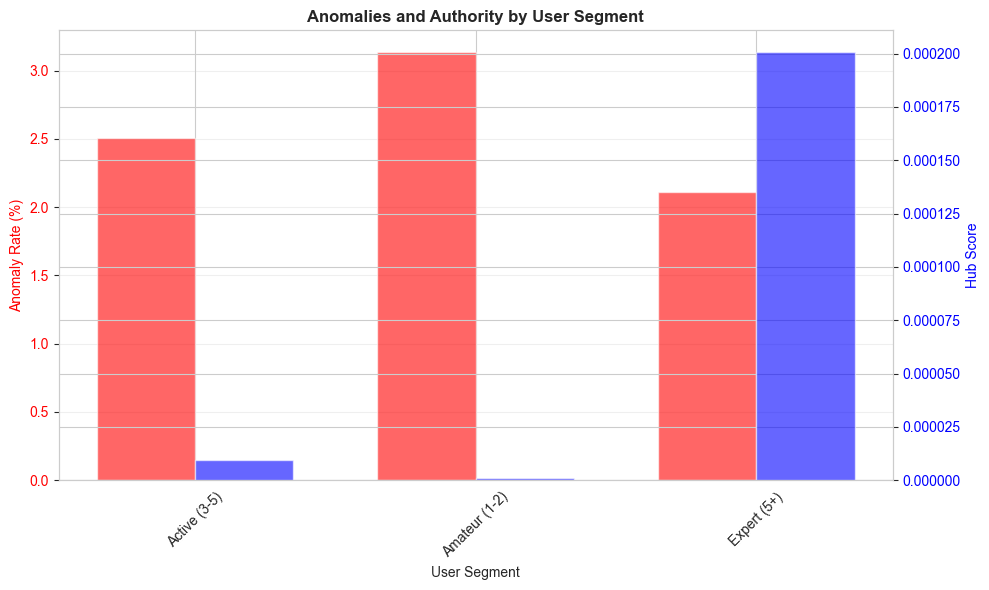

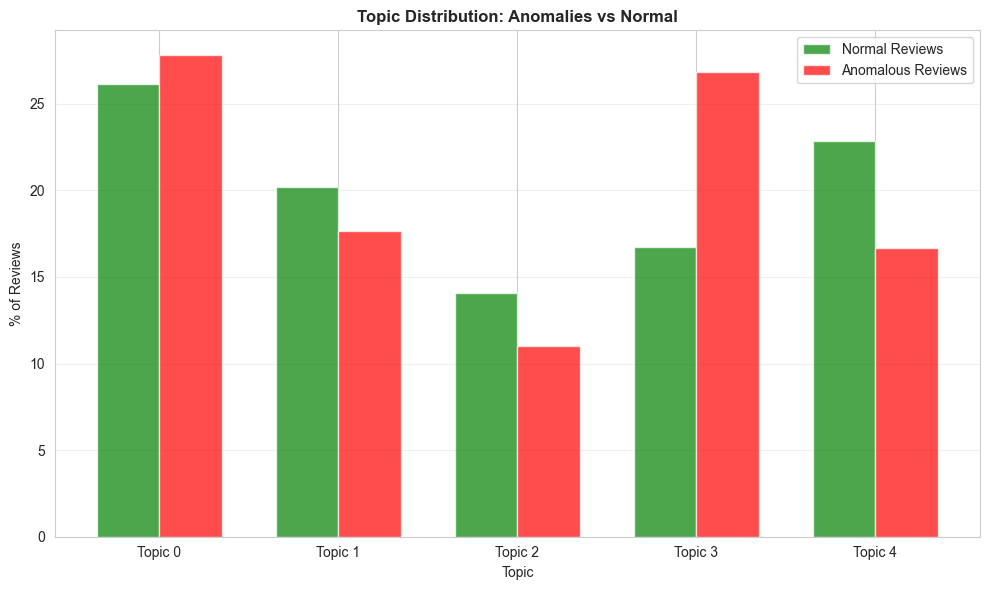

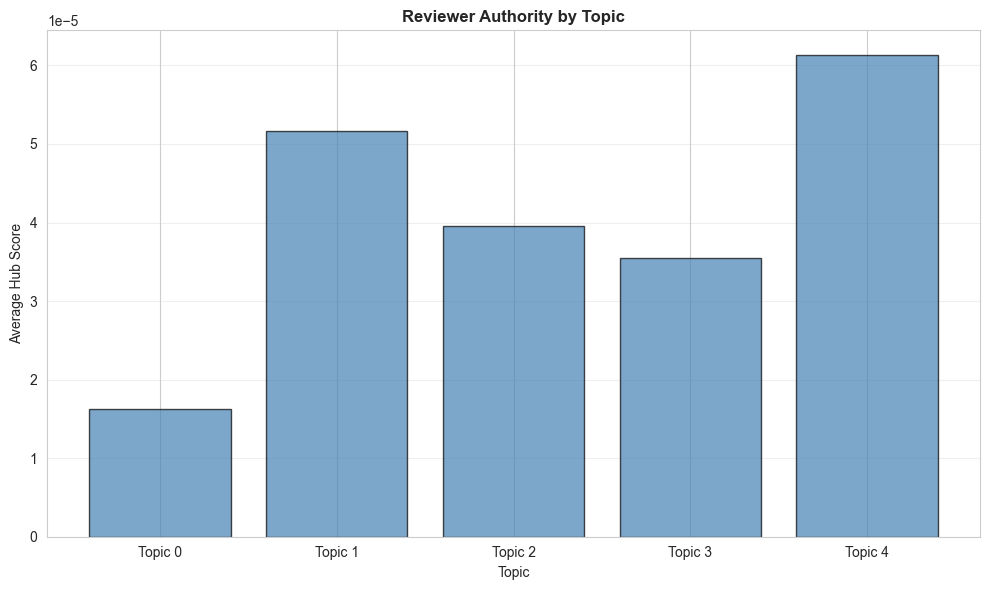

In [17]:
print("Cross-RQ analysis\n")

# RQ1 x RQ2: how does being flagged as an anomaly relate to a reviewer's network authority?
anom_authority_corr = df_lda[['Is_Anomaly', 'Hub_Score']].corr().iloc[0, 1]
print(f"Correlation between Is_Anomaly and Hub_Score: {anom_authority_corr:.4f}")

# RQ1 x RQ3: which topics are over- or under-represented among anomalies?
anom_topics = df_lda[df_lda['Is_Anomaly'] == 1]['Dominant_Topic'].value_counts(normalize=True)
normal_topics = df_lda[df_lda['Is_Anomaly'] == 0]['Dominant_Topic'].value_counts(normalize=True)
print(f"\nTopic share in anomalies vs normal reviews (percentage point difference):")
for topic in range(n_topics):
    if topic in anom_topics.index and topic in normal_topics.index:
        diff_pp = (anom_topics[topic] - normal_topics[topic]) * 100
        direction = "more" if diff_pp > 0 else "less"
        print(f"  Topic {topic}: {direction} common in anomalies by {abs(diff_pp):.1f} pp")

# Plot 1 (RQ1 x RQ2): anomaly rate and avg hub score by user segment
fig, ax1 = plt.subplots(figsize=(10, 6))
anom_by_segment = df_lda.groupby('Segment').agg({
    'Is_Anomaly': 'mean',
    'Hub_Score': 'mean'
})
x = np.arange(len(anom_by_segment))
width = 0.35
ax1_twin = ax1.twinx()
ax1.bar(x - width/2, anom_by_segment['Is_Anomaly']*100, width, label='Anomaly Rate %', color='red', alpha=0.6)
ax1_twin.bar(x + width/2, anom_by_segment['Hub_Score'], width, label='Avg Hub Score', color='blue', alpha=0.6)
ax1.set_xlabel('User Segment')
ax1.set_ylabel('Anomaly Rate (%)', color='red')
ax1_twin.set_ylabel('Hub Score', color='blue')
ax1.set_title('Anomalies and Authority by User Segment', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(anom_by_segment.index, rotation=45)
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='y', labelcolor='red')
ax1_twin.tick_params(axis='y', labelcolor='blue')
plt.tight_layout()
plt.show()

# Plot 2 (RQ1 x RQ3): topic distribution for anomalies vs normal reviews
plt.figure(figsize=(10, 6))
anom_topic_dist = df_lda[df_lda['Is_Anomaly'] == 1]['Dominant_Topic'].value_counts(normalize=True).sort_index() * 100
normal_topic_dist = df_lda[df_lda['Is_Anomaly'] == 0]['Dominant_Topic'].value_counts(normalize=True).sort_index() * 100
x = np.arange(len(anom_topic_dist))
width = 0.35
plt.bar(x - width/2, normal_topic_dist.values, width, label='Normal Reviews', alpha=0.7, color='green')
plt.bar(x + width/2, anom_topic_dist.values, width, label='Anomalous Reviews', alpha=0.7, color='red')
plt.xlabel('Topic')
plt.ylabel('% of Reviews')
plt.title('Topic Distribution: Anomalies vs Normal', fontweight='bold')
plt.xticks(x, [f'Topic {i}' for i in range(n_topics)])
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Plot 3 (RQ2 x RQ3): average hub score by dominant topic
plt.figure(figsize=(10, 6))
topic_means = [df_lda[df_lda['Dominant_Topic'] == t]['Hub_Score'].mean() for t in range(n_topics)]
plt.bar(range(n_topics), topic_means, color='steelblue', alpha=0.7, edgecolor='black')
plt.xlabel('Topic')
plt.ylabel('Average Hub Score')
plt.title('Reviewer Authority by Topic', fontweight='bold')
plt.xticks(range(n_topics), [f'Topic {i}' for i in range(n_topics)])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


### Cross-RQ Plots

- Anomalies and authority by segment: Amateurs have the highest anomaly rate and the lowest average hub score. Experts have the lowest anomaly rate and the highest hub score. At the per-review level the correlation between Is_Anomaly and Hub_Score is weak at -0.02 — so high-authority reviewers are not individually immune to being flagged — but segment by segment, the most-flagged group is also the least central in the network.

- Topic distribution for anomalies vs normal reviews: the sharpest result in this whole section. Topic 3 (the generic-usage topic — "like", "use", "day", "first", "work") is 10.1 percentage points (pp) more common among anomalous reviews than normal ones. All three product-specific topics are under-represented in anomalies: pet food by 2.6 pp, cooking and ingredients by 3.0 pp, coffee and tea by 6.2 pp. Topic 0 (shopping and delivery experience) is also slightly over-represented in anomalies by 1.7 pp, in the same direction as Topic 3 — both topics are about something other than the product itself. Flagged reviews are disproportionately written in generic or transactional language rather than product-specific language.

- Reviewer authority by topic: hub scores differ across topics, meaning different product areas attract different kinds of reviewers. A helpfulness model that ignores topic and user segment is mixing several distributions together. The pattern lines up with the RQ3 segment crosstab — topics that lean Expert (pet food, cooking, coffee and tea) tend to show higher average hub scores than topics that lean Amateur (shopping experience and generic usage). That overlap is essentially RQ2 × RQ3 in one picture: the prolific, network-central users gravitate toward specific product-content topics rather than transactional or generic ones, which is also why centrality alone correlated negatively with helpfulness in RQ2.

The Topic 3 result is worth calling out. RQ3 independently found that Topic 3 reviews are less likely to receive helpful votes. Now we see the same topic is also over-represented among RQ1 anomalies. Two unsupervised signals — sentiment-rating mismatch and content theme — built from different data and different algorithms, land on the same kind of reviews. That convergence is stronger evidence than either signal alone.

# Conclusion

### Did We Achieve What We Set Out To Do?

Yes. The project set out to show that unsupervised data mining can surface review authenticity signals at scale without any labeled training data, and it delivered on that across a real 394,000-review corpus. Three independent methods — sentiment-rating residual analysis with Isolation Forest, HITS-based network authority on a user-product bipartite graph, and LDA topic modeling — each produced statistically significant, interpretable results, and when combined they told a coherent story about what a trustworthy review looks like.

### What the Project Accomplished

1. A working three-signal consensus filter. The pipeline flagged 11,232 reviews (2.85%) as anomalies, and that rate lines up cleanly with external estimates of fake-review prevalence in the low single digits. An unsupervised method landing on a sensible calibration with no training labels is a respectable outcome, and it was only possible because we combined three independent filters rather than relying on a single threshold.

2. A counterintuitive, well-supported finding on reviewer authority. Users who sit at the center of the user-product network do not write the most helpful reviews — if anything, they write slightly less helpful ones on average. This runs against the default assumption behind centrality-based ranking and is a genuine result of running the analysis, not a prior belief confirmed by data.

3. Clean, interpretable latent themes. LDA produced five distinct topics on the first fit, each labelable directly from its top words: shopping experience, pet food, cooking and ingredients, generic usage, and coffee and tea. No manual topic cleanup, re-fitting, or forced merging was needed. The resulting topic distribution was then shown to differ meaningfully across user segments (amateurs lean toward shopping experience; experts toward product content) and across helpful vs unhelpful reviews.

4. Genuine cross-method convergence. The generic-language topic is both over-represented among RQ1 anomalies by 10.1 percentage points AND under-represented among helpful reviews by 3.1 percentage points. Two methods built from completely different data — text-rating alignment and word co-occurrence — landed on the same kind of review. This convergence is the project's single strongest piece of internal validation, and it is only visible because we ran all three analyses and cross-compared them.


## References and Citations

```
On my honor, I declare the following resources:
1. Collaborators:
- None

2. Web Sources:
- https://www.kaggle.com/
- https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews/data

3. AI Tools:
- Claude : I asked Claude to help in implementing code for VADER, Isolation Forest, HITS and LDA. Combining three RQs and analysing the results.  Help in analysing the results obtained and formatting the responses to all the sections.

4. Citations:
- J. McAuley and J. Leskovec. From amateurs to connoisseurs: modeling the evolution of user expertise through online reviews. WWW, 2013.

```


